# ДЗ №3. Технический анализ — улучшение торговой стратегии

**Студент**: Сизиков Константин

**Цель**:
Студент научится строить конвейер тестирования торговой стратегии.
Результат - конвейер оценки качества торговой стратегии, готовый для дальнейшего использования при построении моделей.

**Описание/Пошаговая инструкция выполнения домашнего задания**:
 - Создать код на Python, который разделит ваши данные на тренировочный, тестовый и валидационный наборы данных.
 - Построить одну или несколько моделей на основе классификации, которая будет принимать торговые решения по бумагам SnP500 и/или криптовалютам.
 - Построить конвейер обратного тестирования полученной стратегии.
 - Провести подбор гиперпараметров моделей с использованием обучающей и тестовой выборок.
 - Провести финальное тестирование построенных торговых стратегий на валидационном наборе данных и сравнить их между собой.
 - Сформировать дашборд, показывающий эффективность различных стратегий во времени.

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter
from matplotlib.patches import Rectangle

from scipy import stats
from scipy.optimize import brentq

from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve)
from catboost import CatBoostClassifier

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
PERIODS_PER_YEAR = 24 * 365
FEE_RATE = 0.001          # та же комиссия, что в ДЗ №2, — чтобы результаты были сопоставимы
FEE_SCENARIOS = {"0.10% (ДЗ №2)": 0.0010, "0.05% (taker)": 0.0005,
                 "0.02% (maker)": 0.0002, "0.00% (без издержек)": 0.0}
N_CV_SPLITS = 5
N_TRIALS = 25
TRAIN_END, TEST_END = 0.70, 0.85     # доли ряда: train / train+test, остальное — валидация
HORIZON = 1               # горизонт прогноза в барах (обоснование — раздел 13)
EMBARGO = HORIZON         # разрыв между выборками = длине метки
WINSOR_Q = 0.001          # квантиль винзоризации признаков
OUTLIER_Z = 4.0           # порог робастного z-score для «экстремального» бара
OUTLIER_WEIGHT = 0.25     # вес аномального бара при обучении
PIVOT_W = 5               # полуокно фрактала для свинг-точек
N_BLOCKS = 5              # число подпериодов для проверки устойчивости торгового слоя
MIN_POSITIVE_BLOCKS = 3   # сколько подпериодов должны быть прибыльными
MIN_TURNOVER_PER_YEAR = 6  # минимальный оборот: 3 полных разворота позиции в год
MIN_AVG_EXPOSURE = 0.10    # минимальный средний размер позиции (доля капитала)
TRADE_EPS = 0.01           # изменение позиции меньше 1% капитала сделкой не считается
N_LAGS = 12

DATA_PATH = "data/btc_1h.csv"

np.random.seed(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 110

CLS_COLS = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
TRADE_COLS = ["gross_return", "fee_drag", "total_return", "sharpe", "max_drawdown",
              "n_trades", "turnover_units", "avg_abs_position"]
REPORT_COLS = CLS_COLS + TRADE_COLS

COLORS = {
    "BuyAndHold": "#44403c",
    "HW2_Baseline": "#a8a29e",
    "TA_AlwaysIn": "#c026d3",
    "LogisticRegression": "#2a78d6",
    "DecisionTree": "#eb6834",
    "CatBoost": "#1baf7a",
    "Ensemble": "#8b5cf6",
}
STYLES = {"BuyAndHold": (0, (5, 2)), "HW2_Baseline": (0, (1, 1.6)),
          "TA_AlwaysIn": (0, (3, 1.4))}
SHORT = {"BuyAndHold": "B&H", "HW2_Baseline": "ДЗ№2", "TA_AlwaysIn": "ТА без слоя",
         "LogisticRegression": "LogReg", "DecisionTree": "Tree", "CatBoost": "CatBoost",
         "Ensemble": "Ансамбль"}
INK, INK_MUTED, GRID = "#1c1917", "#57534e", "#e7e5e4"

UP, DOWN = "#1baf7a", "#e05252"      # цвета растущей / падающей свечи


def style_ax(ax, ygrid=True, xgrid=False):
    """Единое оформление осей: без рамки, приглушённая сетка."""
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(GRID)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    if ygrid:
        ax.grid(axis="y", color=GRID, linewidth=0.7)
    if xgrid:
        ax.grid(axis="x", color=GRID, linewidth=0.7)
    ax.set_axisbelow(True)

## 1. Загрузка данных и проверка целостности

Часовые бары BTC/USDT. Проверка на дубли меток времени, пропущенные часы, нарушенные соотношения OHLC
(`high` должен быть не меньше `max(open, close)`, `low` — не больше `min(open, close)`),
неположительные цены и нулевой объём.

In [2]:
raw = pd.read_csv(DATA_PATH)

COLUMN_MAP = {"datetime": "date", "date": "date", "open": "open", "high": "high",
              "low": "low", "close": "close", "volume": "volume"}
raw = raw.rename(columns={c: COLUMN_MAP[c.lower()] for c in raw.columns if c.lower() in COLUMN_MAP})
assert not raw.columns.duplicated().any(), f"После переименования появились дубли колонок: {list(raw.columns)}"

OHLCV = ["open", "high", "low", "close", "volume"]
absent = [c for c in ["date"] + OHLCV if c not in raw.columns]
assert not absent, f"В {DATA_PATH} нет обязательных колонок {absent}; фактически есть: {list(raw.columns)}"

raw["date"] = pd.to_datetime(raw["date"], utc=True).dt.tz_convert(None)

n_before = len(raw)
dup_rows = raw.duplicated(subset="date", keep=False).sum()
conflicting = 0
if dup_rows:
    g = raw[raw.duplicated(subset="date", keep=False)].groupby("date").nunique()
    conflicting = int((g[OHLCV] > 1).any(axis=1).sum())

raw = raw.sort_values("date").drop_duplicates(subset="date").reset_index(drop=True)
full_grid = pd.date_range(raw["date"].min(), raw["date"].max(), freq="h")
missing = full_grid.difference(raw["date"])

o, h, l, c, v = (raw[x] for x in OHLCV)
integrity = pd.DataFrame([
    ("дубли меток времени", int(dup_rows), "удалены" if dup_rows else "—"),
    ("  из них с расхождением в OHLCV", conflicting, "критично" if conflicting else "—"),
    ("пропущенные часы в сетке", int(len(missing)), "критично" if len(missing) else "—"),
    ("high < max(open, close)", int((h < np.maximum(o, c) - 1e-9).sum()), "битый бар"),
    ("low > min(open, close)", int((l > np.minimum(o, c) + 1e-9).sum()), "битый бар"),
    ("high < low", int((h < l).sum()), "битый бар"),
    ("неположительные цены", int((raw[["open", "high", "low", "close"]] <= 0).sum().sum()), "битый бар"),
    ("нулевой объём", int((v <= 0).sum()), "нет торгов"),
    ("нулевой диапазон (high == low)", int(((h - l) <= 0).sum()), "нет движения"),
], columns=["проверка", "нарушений", "трактовка"]).set_index("проверка")

print(f"Загружено строк: {n_before}")
display(integrity)
assert conflicting == 0, "Дубликаты timestamp содержат разные котировки — нужно решить, какую строку оставить"
assert len(missing) == 0, f"В ряду есть пропуски ({len(missing)} часов) — лаговые признаки будут смещены во времени"
assert (h >= np.maximum(o, c) - 1e-9).all() and (l <= np.minimum(o, c) + 1e-9).all(), "нарушена структура OHLC"
print(f"OK: непрерывный часовой ряд без дефектов, {len(raw)} баров, "
      f"период {raw['date'].min()} — {raw['date'].max()}")

raw = raw[["date"] + OHLCV]
raw.head()

Загружено строк: 48625


,нарушений,трактовка
проверка,,
дубли меток времени,0,—
из них с расхождением в OHLCV,0,—
пропущенные часы в сетке,0,—
"high < max(open, close)",0,битый бар
"low > min(open, close)",0,битый бар
high < low,0,битый бар
неположительные цены,0,битый бар
нулевой объём,0,нет торгов
нулевой диапазон (high == low),0,нет движения


OK: непрерывный часовой ряд без дефектов, 48625 баров, период 2021-01-01 00:00:00 — 2026-07-20 00:00:00


,date,open,high,low,close,volume
0,2021-01-01 00:00:00,28921.5,29026.0,28703.5,28990.0,917.494
1,2021-01-01 01:00:00,28990.0,29505.5,28956.5,29411.0,1927.830
2,2021-01-01 02:00:00,29411.0,29462.0,29150.0,29218.0,931.537
3,2021-01-01 03:00:00,29218.0,29358.5,29171.5,29303.0,440.535
4,2021-01-01 04:00:00,29303.0,29397.5,29078.0,29229.5,711.549


### 1.1 Обзор ряда

Отдельно смотрим на структуру гэпов: у круглосуточного крипторынка `open` следующего бара
почти всегда в точности равен `close` предыдущего. Это важно для свечных паттернов —
классические определения «пронзающей линии», «завесы из тёмных облаков» и «камикадзе» требуют
ценового разрыва, которого здесь физически не бывает, поэтому их придётся переопределить.

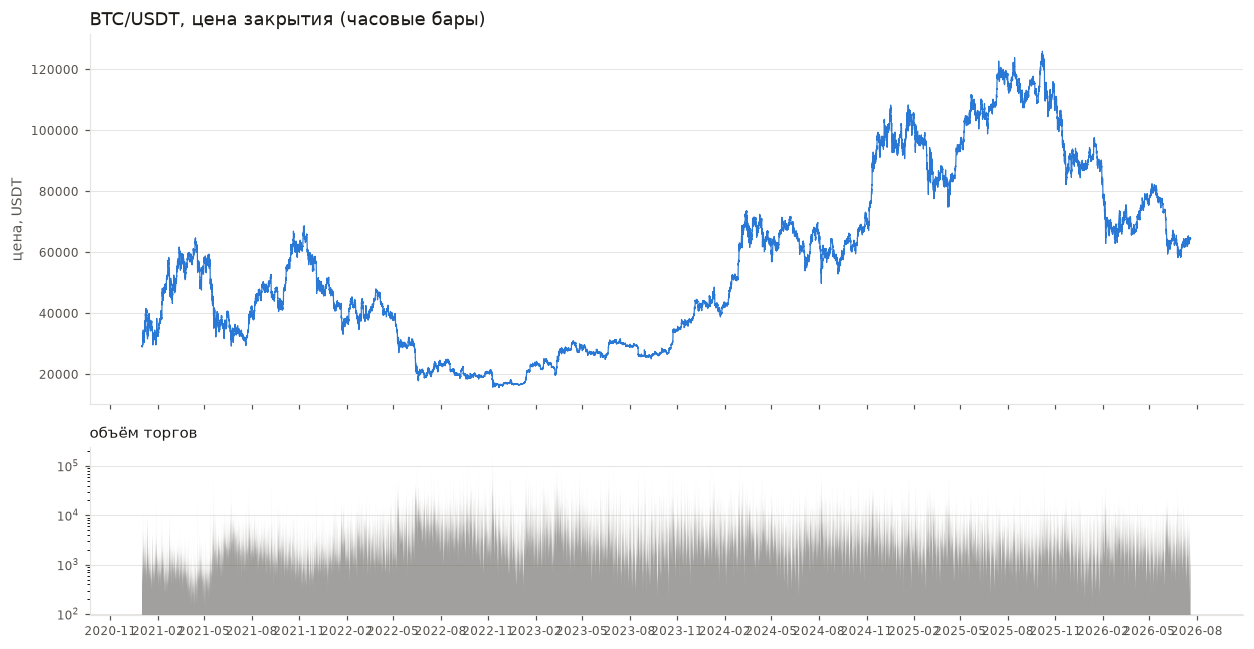

Баров с ценовым разрывом (open != предыдущий close): 66 из 48624 (0.14%), максимальный разрыв 40.0 USDT
Часовая доходность: std=0.6254%, эксцесс=17.7 (у нормального распределения 0), диапазон [-9.28%, 12.50%]


In [3]:
gap = raw["open"] - raw["close"].shift(1)
n_gap = int((gap.abs() > 1e-9).sum())
ret_all = raw["close"].pct_change()

fig, axes = plt.subplots(2, 1, figsize=(11.5, 6), sharex=True,
                         gridspec_kw={"height_ratios": [2.2, 1]})
axes[0].plot(raw["date"], raw["close"], color=COLORS["LogisticRegression"], linewidth=0.8)
axes[0].set_title("BTC/USDT, цена закрытия (часовые бары)", color=INK, loc="left", fontsize=11.5)
axes[0].set_ylabel("цена, USDT", color=INK_MUTED, fontsize=9)
axes[1].fill_between(raw["date"], raw["volume"], color=INK_MUTED, linewidth=0, alpha=0.55)
axes[1].set_title("объём торгов", color=INK, loc="left", fontsize=10)
axes[1].set_yscale("log")
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
for ax in axes:
    style_ax(ax)
fig.tight_layout()
plt.show()

print(f"Баров с ценовым разрывом (open != предыдущий close): {n_gap} из {len(raw) - 1} "
      f"({n_gap / (len(raw) - 1):.2%}), максимальный разрыв {gap.abs().max():.1f} USDT")
print(f"Часовая доходность: std={ret_all.std():.4%}, эксцесс={ret_all.kurtosis():.1f} "
      f"(у нормального распределения 0), диапазон [{ret_all.min():.2%}, {ret_all.max():.2%}]")

## 2. Поиск аномалий (выбросов) и их обработка

Проверка на **рыночные выбросы**:
бары с экстремальным движением цены или объёма.

| шаг | что делается | зачем |
|---|---|---|
| обнаружение | робастный z-score (медиана + MAD) по доходности, объёму и истинному диапазону | MAD, в отличие от std, не «раздувается» самими выбросами |
| обнаружение | многомерный `IsolationForest` по причинным признакам бара | ловит аномальные *сочетания* (например, большой объём при нулевом движении) |
| признаки | сами z-оценки и флаги аномальности идут в модель как признаки | кластеризация волатильности — это предсказательная информация |
| ограничение | винзоризация всех признаков по квантилям **обучающей** выборки | убирает влияние хвостов, не удаляя строки из ряда |
| ограничение | понижающий вес аномальных баров в функции потерь | модель их видит, но они не доминируют |

Строки **не удаляются**. Временной ряд обязан остаться непрерывным,
иначе лаговые признаки будут ссылаться на несуществующие соседние бары, а бэктест — «телепортировать»
капитал через выброшенные часы, завышая результат (именно на пропущенных барах и случаются
самые большие убытки).

In [4]:
# Общие вспомогательные функции: нужны и для поиска аномалий, и для индикаторов ТА.

def wilder(s, n):
    """Сглаживание Уайлдера (RSI/ATR/ADX): экспоненциальное среднее с alpha = 1/n."""
    return s.ewm(alpha=1.0 / n, adjust=False).mean()


def true_range(high, low, close):
    """Истинный диапазон бара с учётом разрыва от предыдущего закрытия."""
    pc = close.shift(1)
    return pd.concat([high - low, (high - pc).abs(), (low - pc).abs()], axis=1).max(axis=1)


def zscore(s, n):
    return (s - s.rolling(n).mean()) / s.rolling(n).std(ddof=0).replace(0, np.nan)


def robust_z(s, n):
    """Робастная z-оценка: (x - медиана) / (1.4826 * MAD) по скользящему окну.

    1.4826 — коэффициент, при котором MAD нормального распределения равен его std,
    поэтому пороги можно трактовать в «сигмах». В отличие от обычного z-score,
    оценка не портится самими выбросами: одна свеча в ±10% не сдвигает медиану.
    """
    med = s.rolling(n).median()
    mad = (s - med).abs().rolling(n).median()
    return (s - med) / (1.4826 * mad).replace(0, np.nan)

### 2.1 Одномерные выбросы: робастные z-оценки

In [5]:
ANOM_WIN = 168        # окно оценки «нормы» — одна неделя часовых баров

ret1 = raw["close"].pct_change()
tr = true_range(raw["high"], raw["low"], raw["close"])
logv = np.log1p(raw["volume"])

anom_z = pd.DataFrame({
    "доходность": robust_z(ret1, ANOM_WIN),
    "объём": robust_z(logv, ANOM_WIN),
    "истинный диапазон": robust_z(tr, ANOM_WIN),
})
anom_flags = anom_z.abs() > OUTLIER_Z

summary = pd.DataFrame({
    "выбросов": anom_flags.sum(),
    "доля": (anom_flags.mean() * 100).round(2).astype(str) + "%",
    "макс |z|": anom_z.abs().max().round(1),
    "порог по обычному z": [(np.abs(zscore(x, ANOM_WIN)) > OUTLIER_Z).sum()
                            for x in (ret1, logv, tr)],
})
summary.index.name = "показатель"
print(f"Порог: |робастный z| > {OUTLIER_Z} при окне {ANOM_WIN} ч")
display(summary)

is_outlier_any = anom_flags.any(axis=1)
print(f"Баров, аномальных хотя бы по одному показателю: {is_outlier_any.sum()} "
      f"({is_outlier_any.mean():.2%})")
print("Последняя колонка показывает, во сколько раз меньше выбросов нашёл бы обычный z-score:")
print("сигма, посчитанная по среднему и std, сама раздувается выбросами и прячет их.\n")

extreme = raw.loc[anom_z["доходность"].abs().nlargest(8).index, ["date", "close", "volume"]].copy()
extreme["доходность"] = (ret1.loc[extreme.index] * 100).round(2).astype(str) + "%"
extreme["робастный z"] = anom_z.loc[extreme.index, "доходность"].round(1)
extreme["z объёма"] = anom_z.loc[extreme.index, "объём"].round(1)
print("Самые экстремальные бары по доходности:")
display(extreme.set_index("date"))

Порог: |робастный z| > 4.0 при окне 168 ч


,выбросов,доля,макс |z|,порог по обычному z
показатель,,,,
доходность,1336,2.75%,46.8,352
объём,44,0.09%,7.4,20
истинный диапазон,1852,3.81%,69.0,460


Баров, аномальных хотя бы по одному показателю: 2204 (4.53%)
Последняя колонка показывает, во сколько раз меньше выбросов нашёл бы обычный z-score:
сигма, посчитанная по среднему и std, сама раздувается выбросами и прячет их.

Самые экстремальные бары по доходности:


,close,volume,доходность,робастный z,z объёма
date,,,,,
2023-08-17 21:00:00,26230.8,85042.204,-5.2%,-46.8,4.3
2023-08-29 14:00:00,27481.7,130484.605,5.53%,37.1,4.7
2023-01-12 17:00:00,18833.5,46472.443,3.9%,30.8,3.4
2023-01-14 00:00:00,20894.0,98605.159,4.95%,29.4,3.6
2022-11-08 17:00:00,19324.5,57086.582,-5.06%,-21.1,3.3
2022-12-13 13:00:00,17878.5,64708.829,2.7%,20.2,3.6
2023-04-26 19:00:00,27871.8,79142.216,-6.24%,-19.3,3.3
2022-12-14 19:00:00,17768.5,63406.765,-2.4%,-19.1,3.5


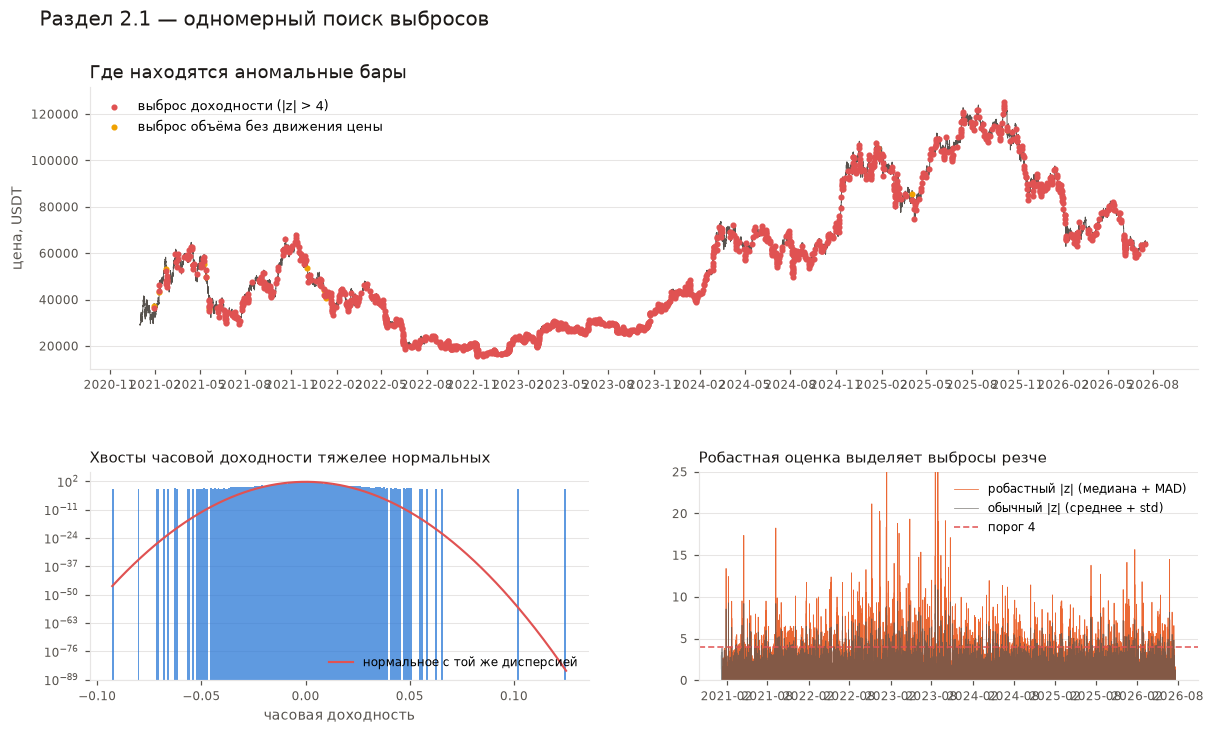

In [6]:
fig = plt.figure(figsize=(13, 7))
gs = fig.add_gridspec(2, 2, height_ratios=[1.35, 1], hspace=0.42, wspace=0.22)

# ── цена с отмеченными выбросами ────────────────────────────────────────────
ax = fig.add_subplot(gs[0, :])
ax.plot(raw["date"], raw["close"], color=INK_MUTED, linewidth=0.6, zorder=1)
out_idx = anom_flags["доходность"]
ax.scatter(raw.loc[out_idx, "date"], raw.loc[out_idx, "close"], s=9,
           color=DOWN, zorder=3, label=f"выброс доходности (|z| > {OUTLIER_Z:.0f})")
vol_only = anom_flags["объём"] & ~anom_flags["доходность"]
ax.scatter(raw.loc[vol_only, "date"], raw.loc[vol_only, "close"], s=9,
           color="#f0a202", zorder=2, label="выброс объёма без движения цены")
ax.set_title("Где находятся аномальные бары", color=INK, loc="left", fontsize=11.5)
ax.set_ylabel("цена, USDT", color=INK_MUTED, fontsize=9)
ax.legend(frameon=False, fontsize=8.5, loc="upper left")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
style_ax(ax)

# ── распределение доходности против нормального ─────────────────────────────
ax = fig.add_subplot(gs[1, 0])
r = ret1.dropna()
ax.hist(r, bins=250, color=COLORS["LogisticRegression"], alpha=0.75, density=True, linewidth=0)
xs = np.linspace(r.min(), r.max(), 500)
ax.plot(xs, stats.norm.pdf(xs, r.mean(), r.std()), color=DOWN, linewidth=1.4,
        label="нормальное с той же дисперсией")
ax.set_yscale("log")
ax.set_title("Хвосты часовой доходности тяжелее нормальных", color=INK, loc="left", fontsize=10)
ax.set_xlabel("часовая доходность", color=INK_MUTED, fontsize=9)
ax.legend(frameon=False, fontsize=8)
style_ax(ax)

# ── robust z против обычного z ──────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
ax.plot(raw["date"], anom_z["доходность"].abs(), color=COLORS["DecisionTree"], linewidth=0.5,
        label="робастный |z| (медиана + MAD)")
ax.plot(raw["date"], zscore(ret1, ANOM_WIN).abs(), color=INK_MUTED, linewidth=0.5, alpha=0.7,
        label="обычный |z| (среднее + std)")
ax.axhline(OUTLIER_Z, color=DOWN, linewidth=1.0, linestyle=(0, (4, 2)),
           label=f"порог {OUTLIER_Z:.0f}")
ax.set_title("Робастная оценка выделяет выбросы резче", color=INK, loc="left", fontsize=10)
ax.set_ylim(0, 25)
ax.legend(frameon=False, fontsize=8)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
style_ax(ax)

fig.suptitle("Раздел 2.1 — одномерный поиск выбросов", fontsize=13, color=INK, x=0.09, ha="left",
             y=0.98)
plt.show()

### 2.2 Многомерные аномалии: IsolationForest

Одномерные оценки не видят аномальных *сочетаний*: бар с обычной по величине доходностью, но
аномальным для неё объёмом и формой свечи, по каждому показателю в отдельности выглядит
нормальным. `IsolationForest` строит случайные деревья и измеряет, за сколько расщеплений
наблюдение удаётся отделить от остальных: выброс отделяется быстро.

Детектор обучается **только на обучающей части ряда** (первые 70%) и применяется ко всему ряду —
так же, как это происходило бы в реальной эксплуатации, когда будущего мы не знаем.

Порог аномальности (99-й перцентиль по train): 0.662
Помечено IsolationForest: 418 баров (0.86%)



IsolationForest,False,True
одномерный выброс,,
False,46381,40
True,1826,378


40 баров (0.08%) аномальны только как сочетание признаков — одномерные оценки их не видят.


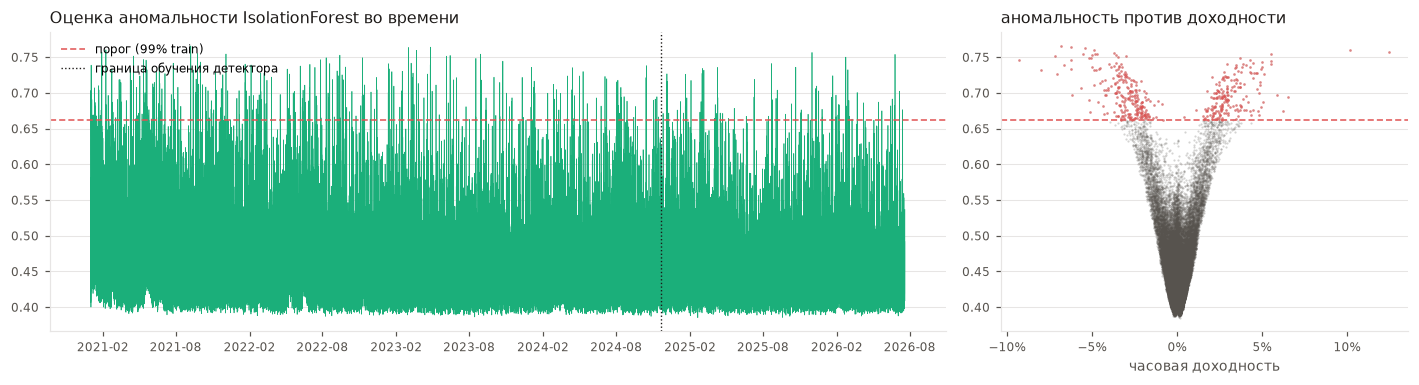

In [7]:
n_raw = len(raw)
train_bound = int(n_raw * TRAIN_END)

# компактный набор причинных характеристик бара
atr14_raw = wilder(true_range(raw["high"], raw["low"], raw["close"]), 14)
rng_raw = (raw["high"] - raw["low"]).replace(0, np.nan)
iso_input = pd.DataFrame({
    "ret": ret1,
    "abs_ret": ret1.abs(),
    "tr_atr": tr / atr14_raw.replace(0, np.nan),
    "vol_z": zscore(logv, ANOM_WIN),
    "body_frac": (raw["close"] - raw["open"]).abs() / rng_raw,
    "clv": ((raw["close"] - raw["low"]) - (raw["high"] - raw["close"])) / rng_raw,
}).replace([np.inf, -np.inf], np.nan)
iso_input = iso_input.ffill().bfill()

iso = IsolationForest(n_estimators=300, contamination=0.01, random_state=RANDOM_STATE, n_jobs=-1)
iso.fit(iso_input.iloc[:train_bound])
iso_score = pd.Series(-iso.score_samples(iso_input), index=raw.index)   # больше = аномальнее
iso_thr = float(np.quantile(iso_score.iloc[:train_bound], 0.99))
iso_flag = iso_score > iso_thr

overlap = pd.crosstab(is_outlier_any.rename("одномерный выброс"),
                      iso_flag.rename("IsolationForest"))
print(f"Порог аномальности (99-й перцентиль по train): {iso_thr:.3f}")
print(f"Помечено IsolationForest: {iso_flag.sum()} баров ({iso_flag.mean():.2%})\n")
display(overlap)
found_only_by_iso = int(((~is_outlier_any) & iso_flag).sum())
print(f"{found_only_by_iso} баров ({found_only_by_iso / len(raw):.2%}) аномальны только как "
      f"сочетание признаков — одномерные оценки их не видят.")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), gridspec_kw={"width_ratios": [2.2, 1]})
axes[0].plot(raw["date"], iso_score, color=COLORS["CatBoost"], linewidth=0.45)
axes[0].axhline(iso_thr, color=DOWN, linewidth=1.0, linestyle=(0, (4, 2)), label="порог (99% train)")
axes[0].axvline(raw["date"].iloc[train_bound], color=INK, linewidth=0.9, linestyle=":",
                label="граница обучения детектора")
axes[0].set_title("Оценка аномальности IsolationForest во времени", color=INK, loc="left", fontsize=10.5)
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
style_ax(axes[0])

axes[1].scatter(ret1, iso_score, s=2, alpha=0.25, color=INK_MUTED, linewidth=0)
axes[1].scatter(ret1[iso_flag], iso_score[iso_flag], s=3, alpha=0.6, color=DOWN, linewidth=0)
axes[1].axhline(iso_thr, color=DOWN, linewidth=1.0, linestyle=(0, (4, 2)))
axes[1].set_xlabel("часовая доходность", color=INK_MUTED, fontsize=9)
axes[1].set_title("аномальность против доходности", color=INK, loc="left", fontsize=10.5)
axes[1].xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
style_ax(axes[1])
fig.tight_layout()
plt.show()

Вертикальная «стенка» точек в правой панели показывает главное: высокая оценка аномальности
встречается и при доходности, близкой к нулю. Это как раз бары с аномальным объёмом или формой
свечи при спокойной цене — их одномерный фильтр по доходности пропускает.

## 3. Библиотека индикаторов технического анализа

In [8]:
def rsi(close, n=14):
    """Индекс относительной силы: отношение среднего роста к среднему падению за n баров."""
    d = close.diff()
    gain = wilder(d.clip(lower=0), n)
    loss = wilder((-d).clip(lower=0), n)
    out = 100 - 100 / (1 + gain / loss.where(loss > 0))
    # loss == 0: рост без падений -> 100; полный штиль -> нейтральные 50
    return out.where(loss > 0, np.where(gain > 0, 100.0, 50.0))


def atr(high, low, close, n=14):
    """Средний истинный диапазон — базовая мера волатильности в единицах цены."""
    return wilder(true_range(high, low, close), n)


def stochastic(high, low, close, n=14, d=3):
    """Стохастик: положение закрытия внутри диапазона последних n баров."""
    ll, hh = low.rolling(n).min(), high.rolling(n).max()
    k = 100 * (close - ll) / (hh - ll).replace(0, np.nan)
    return k, k.rolling(d).mean()


def macd(close, fast=12, slow=26, signal=9):
    """Схождение/расхождение скользящих средних: линия, сигнал и гистограмма."""
    line = close.ewm(span=fast, adjust=False).mean() - close.ewm(span=slow, adjust=False).mean()
    sig = line.ewm(span=signal, adjust=False).mean()
    return line, sig, line - sig


def adx(high, low, close, n=14):
    """Индекс направленного движения: сила тренда (ADX) и его направление (+DI / -DI)."""
    up, dn = high.diff(), -low.diff()
    plus_dm = pd.Series(np.where((up > dn) & (up > 0), up, 0.0), index=high.index)
    minus_dm = pd.Series(np.where((dn > up) & (dn > 0), dn, 0.0), index=high.index)
    tr_n = wilder(true_range(high, low, close), n).replace(0, np.nan)
    plus_di = 100 * wilder(plus_dm, n) / tr_n
    minus_di = 100 * wilder(minus_dm, n) / tr_n
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di).replace(0, np.nan)
    return wilder(dx, n), plus_di, minus_di


def cci(high, low, close, n=20):
    """Индекс товарного канала: отклонение типичной цены от среднего в единицах среднего отклонения."""
    tp = (high + low + close) / 3
    sma = tp.rolling(n).mean()
    mad = (tp - sma).abs().rolling(n).mean()
    return (tp - sma) / (0.015 * mad.replace(0, np.nan))


def mfi(high, low, close, volume, n=14):
    """Индекс денежного потока — RSI, взвешенный объёмом."""
    tp = (high + low + close) / 3
    raw_flow = tp * volume
    up = raw_flow.where(tp > tp.shift(1), 0.0).rolling(n).sum()
    dn = raw_flow.where(tp < tp.shift(1), 0.0).rolling(n).sum()
    return 100 - 100 / (1 + up / dn.replace(0, np.nan))


def clv(high, low, close):
    """Close Location Value: положение закрытия внутри диапазона бара, от -1 до +1."""
    return ((close - low) - (high - close)) / (high - low).replace(0, np.nan)


def cmf(high, low, close, volume, n=20):
    """Денежный поток Чайкина: объём, взвешенный положением закрытия в баре."""
    return ((clv(high, low, close).fillna(0) * volume).rolling(n).sum()
            / volume.rolling(n).sum().replace(0, np.nan))


def obv(close, volume):
    """Балансовый объём: накопленный объём со знаком движения цены."""
    return (np.sign(close.diff().fillna(0)) * volume).cumsum()


def aroon(high, low, n=25):
    """Aroon: как давно был максимум и минимум окна (100 = прямо сейчас)."""
    hi = high.rolling(n + 1).apply(lambda x: float(np.argmax(x)), raw=True)
    lo = low.rolling(n + 1).apply(lambda x: float(np.argmin(x)), raw=True)
    return 100 * hi / n, 100 * lo / n


def efficiency_ratio(close, n=20):
    """Коэффициент эффективности Кауфмана: 1 — чистый тренд, 0 — «пила» без смещения."""
    direction = (close - close.shift(n)).abs()
    path = close.diff().abs().rolling(n).sum()
    return direction / path.replace(0, np.nan)


# демонстрация на последних сутках
demo = raw.tail(500).reset_index(drop=True)
_adx, _pdi, _mdi = adx(demo["high"], demo["low"], demo["close"])
demo_ind = pd.DataFrame({
    "RSI(14)": rsi(demo["close"]), "ATR(14)": atr(demo["high"], demo["low"], demo["close"]),
    "ADX(14)": _adx, "CCI(20)": cci(demo["high"], demo["low"], demo["close"]),
    "MFI(14)": mfi(demo["high"], demo["low"], demo["close"], demo["volume"]),
    "ER(20)": efficiency_ratio(demo["close"]),
}).tail(3).round(3)
print("Проверка индикаторов на последних барах ряда:")
display(demo_ind)

Проверка индикаторов на последних барах ряда:


,RSI(14),ATR(14),ADX(14),CCI(20),MFI(14),ER(20)
497,57.898,221.976,21.652,27.555,59.986,0.103
498,59.741,221.299,22.195,51.961,66.703,0.007
499,51.046,257.471,23.874,57.014,72.189,0.116


## 4. Свечные паттерны

Реализовано 31 определение: однобарные (доджи, молот, перевёрнутый молот, падающая звезда,
повешенный, марубозу, волчок, «пояс», надгробие и стрекоза), двухбарные (бычье и медвежье
поглощение, харами, пронзающая линия, завеса из тёмных облаков, пинцеты, внутренний и внешний бар)
и трёхбарные (утренняя и вечерняя звезда, три белых солдата, три чёрные вороны, три внутри вверх/вниз).

In [9]:
def candle_anatomy(o_, h_, l_, c_):
    """Геометрия свечи: тело, тени и их доли в диапазоне бара."""
    rng = (h_ - l_).replace(0, np.nan)
    body = c_ - o_
    return pd.DataFrame({
        "rng": rng, "body": body, "abs_body": body.abs(),
        "upper": h_ - np.maximum(o_, c_), "lower": np.minimum(o_, c_) - l_,
        "body_frac": body.abs() / rng,
        "upper_frac": (h_ - np.maximum(o_, c_)) / rng,
        "lower_frac": (np.minimum(o_, c_) - l_) / rng,
        "clv": clv(h_, l_, c_),
    }, index=o_.index)


CANDLE_BULL = ["cdl_hammer", "cdl_inv_hammer", "cdl_dragonfly_doji", "cdl_marubozu_bull",
               "cdl_engulfing_bull", "cdl_harami_bull", "cdl_piercing", "cdl_tweezer_bottom",
               "cdl_morning_star", "cdl_three_white_soldiers", "cdl_three_inside_up",
               "cdl_belt_hold_bull", "cdl_outside_bar_bull"]
CANDLE_BEAR = ["cdl_hanging_man", "cdl_shooting_star", "cdl_gravestone_doji", "cdl_marubozu_bear",
               "cdl_engulfing_bear", "cdl_harami_bear", "cdl_dark_cloud", "cdl_tweezer_top",
               "cdl_evening_star", "cdl_three_black_crows", "cdl_three_inside_down",
               "cdl_belt_hold_bear", "cdl_outside_bar_bear"]
CANDLE_NEUTRAL = ["cdl_doji", "cdl_long_legged_doji", "cdl_spinning_top", "cdl_high_wave",
                  "cdl_inside_bar"]
CANDLE_ALL = CANDLE_BULL + CANDLE_BEAR + CANDLE_NEUTRAL

CANDLE_RU = {
    "cdl_hammer": "молот", "cdl_inv_hammer": "перевёрнутый молот",
    "cdl_dragonfly_doji": "доджи-стрекоза", "cdl_marubozu_bull": "марубозу бычий",
    "cdl_engulfing_bull": "бычье поглощение", "cdl_harami_bull": "харами бычий",
    "cdl_piercing": "пронзающая линия", "cdl_tweezer_bottom": "пинцет снизу",
    "cdl_morning_star": "утренняя звезда", "cdl_three_white_soldiers": "три белых солдата",
    "cdl_three_inside_up": "три внутри вверх", "cdl_belt_hold_bull": "бычий пояс",
    "cdl_outside_bar_bull": "внешний бар бычий", "cdl_hanging_man": "повешенный",
    "cdl_shooting_star": "падающая звезда", "cdl_gravestone_doji": "доджи-надгробие",
    "cdl_marubozu_bear": "марубозу медвежий", "cdl_engulfing_bear": "медвежье поглощение",
    "cdl_harami_bear": "харами медвежий", "cdl_dark_cloud": "завеса из тёмных облаков",
    "cdl_tweezer_top": "пинцет сверху", "cdl_evening_star": "вечерняя звезда",
    "cdl_three_black_crows": "три чёрные вороны", "cdl_three_inside_down": "три внутри вниз",
    "cdl_belt_hold_bear": "медвежий пояс", "cdl_outside_bar_bear": "внешний бар медвежий",
    "cdl_doji": "доджи", "cdl_long_legged_doji": "длинноногий доджи",
    "cdl_spinning_top": "волчок", "cdl_high_wave": "высокая волна",
    "cdl_inside_bar": "внутренний бар",
}


def candlestick_patterns(o_, h_, l_, c_, atr_s, trend_win=10):
    """31 свечной паттерн в виде бинарных признаков (0/1)."""
    a = candle_anatomy(o_, h_, l_, c_)
    rng, body, upper, lower = a["rng"], a["abs_body"], a["upper"], a["lower"]
    bull, bear = c_ > o_, c_ < o_
    body_atr = body / atr_s.replace(0, np.nan)

    o1, h1, l1, c1 = o_.shift(1), h_.shift(1), l_.shift(1), c_.shift(1)
    o2, c2 = o_.shift(2), c_.shift(2)
    bull1, bear1 = c1 > o1, c1 < o1
    bull2, bear2 = c2 > o2, c2 < o2
    body1, body2 = (c1 - o1).abs(), (c2 - o2).abs()
    rng1 = (h1 - l1).replace(0, np.nan)

    prior = c_.shift(1) / c_.shift(1 + trend_win) - 1        # тренд ДО текущего бара
    downtrend, uptrend = prior < 0, prior > 0

    long_body = body_atr > 0.8
    small_body = a["body_frac"] < 0.30
    doji_body = a["body_frac"] < 0.10

    p = {}
    # ── однобарные ───────────────────────────────────────────────────────────
    p["cdl_doji"] = doji_body
    p["cdl_long_legged_doji"] = doji_body & (upper > 0.3 * rng) & (lower > 0.3 * rng)
    p["cdl_dragonfly_doji"] = doji_body & (lower > 0.6 * rng) & (upper < 0.1 * rng)
    p["cdl_gravestone_doji"] = doji_body & (upper > 0.6 * rng) & (lower < 0.1 * rng)
    p["cdl_spinning_top"] = small_body & (upper > body) & (lower > body) & ~doji_body
    p["cdl_high_wave"] = small_body & ((upper + lower) / rng > 0.8) & (rng / atr_s > 1.5)

    hammer_shape = (lower >= 2 * body) & (upper <= 0.25 * body.where(body > 0, rng)) & (a["body_frac"] < 0.4)
    star_shape = (upper >= 2 * body) & (lower <= 0.25 * body.where(body > 0, rng)) & (a["body_frac"] < 0.4)
    p["cdl_hammer"] = hammer_shape & downtrend            # та же форма, что и повешенный,
    p["cdl_hanging_man"] = hammer_shape & uptrend         # различает только тренд до неё
    p["cdl_inv_hammer"] = star_shape & downtrend
    p["cdl_shooting_star"] = star_shape & uptrend
    p["cdl_marubozu_bull"] = bull & (a["body_frac"] > 0.90) & long_body
    p["cdl_marubozu_bear"] = bear & (a["body_frac"] > 0.90) & long_body
    p["cdl_belt_hold_bull"] = bull & (a["lower_frac"] < 0.05) & (a["body_frac"] > 0.7) & downtrend
    p["cdl_belt_hold_bear"] = bear & (a["upper_frac"] < 0.05) & (a["body_frac"] > 0.7) & uptrend

    # ── двухбарные ───────────────────────────────────────────────────────────
    p["cdl_engulfing_bull"] = bear1 & bull & (c_ >= o1) & (o_ <= c1) & (body > body1)
    p["cdl_engulfing_bear"] = bull1 & bear & (o_ >= c1) & (c_ <= o1) & (body > body1)
    p["cdl_harami_bull"] = bear1 & bull & (c_ <= o1) & (o_ >= c1) & (body < 0.6 * body1) & (body1 / atr_s > 0.8)
    p["cdl_harami_bear"] = bull1 & bear & (o_ <= c1) & (c_ >= o1) & (body < 0.6 * body1) & (body1 / atr_s > 0.8)
    # условие гэпа ослаблено до нестрогого: на крипторынке разрывов практически не бывает
    p["cdl_piercing"] = bear1 & bull & (o_ <= c1) & (c_ > (o1 + c1) / 2) & (c_ < o1) & (body1 / atr_s > 0.6)
    p["cdl_dark_cloud"] = bull1 & bear & (o_ >= c1) & (c_ < (o1 + c1) / 2) & (c_ > o1) & (body1 / atr_s > 0.6)
    tw_tol = 0.05 * atr_s
    p["cdl_tweezer_bottom"] = bear1 & bull & ((l_ - l1).abs() < tw_tol) & downtrend
    p["cdl_tweezer_top"] = bull1 & bear & ((h_ - h1).abs() < tw_tol) & uptrend
    p["cdl_inside_bar"] = (h_ < h1) & (l_ > l1)
    p["cdl_outside_bar_bull"] = (h_ > h1) & (l_ < l1) & bull
    p["cdl_outside_bar_bear"] = (h_ > h1) & (l_ < l1) & bear

    # ── трёхбарные ───────────────────────────────────────────────────────────
    small1 = body1 < 0.5 * body2
    p["cdl_morning_star"] = (bear2 & (body2 / atr_s > 0.8) & small1 & bull &
                             (c_ > (o2 + c2) / 2) & (c1 < c2))
    p["cdl_evening_star"] = (bull2 & (body2 / atr_s > 0.8) & small1 & bear &
                             (c_ < (o2 + c2) / 2) & (c1 > c2))
    p["cdl_three_white_soldiers"] = (bull2 & bull1 & bull & (c_ > c1) & (c1 > c2) &
                                     ((c1 - o1).abs() / rng1 > 0.6) & (a["body_frac"] > 0.6))
    p["cdl_three_black_crows"] = (bear2 & bear1 & bear & (c_ < c1) & (c1 < c2) &
                                  ((c1 - o1).abs() / rng1 > 0.6) & (a["body_frac"] > 0.6))
    p["cdl_three_inside_up"] = bear2 & bull1 & bull & (c1 <= o2) & (o1 >= c2) & (c_ > o2)
    p["cdl_three_inside_down"] = bull2 & bear1 & bear & (o1 <= c2) & (c1 >= o2) & (c_ < o2)

    return pd.DataFrame(p, index=o_.index).fillna(False).astype(np.int8)[CANDLE_ALL], a


atr14 = atr(raw["high"], raw["low"], raw["close"], 14)
cdl = candlestick_patterns(raw["open"], raw["high"], raw["low"], raw["close"], atr14)[0]

cdl_freq = pd.DataFrame({
    "паттерн": [CANDLE_RU[c] for c in cdl.columns],
    "тип": ["бычий" if c in CANDLE_BULL else "медвежий" if c in CANDLE_BEAR else "нейтральный"
            for c in cdl.columns],
    "срабатываний": cdl.sum().to_numpy(),
    "частота, %": (cdl.mean() * 100).round(2).to_numpy(),
}, index=cdl.columns).sort_values("срабатываний", ascending=False)
print(f"Распознано {len(cdl.columns)} свечных паттернов, "
      f"{int(cdl.sum().sum())} срабатываний на {len(cdl)} барах")
display(cdl_freq)

Распознано 31 свечных паттернов, 57300 срабатываний на 48625 барах


,паттерн,тип,срабатываний,"частота, %"
cdl_inside_bar,внутренний бар,нейтральный,8984,18.48
cdl_spinning_top,волчок,нейтральный,6304,12.96
cdl_engulfing_bull,бычье поглощение,бычий,6163,12.67
cdl_engulfing_bear,медвежье поглощение,медвежий,5997,12.33
cdl_doji,доджи,нейтральный,5276,10.85
cdl_long_legged_doji,длинноногий доджи,нейтральный,2539,5.22
cdl_outside_bar_bull,внешний бар бычий,бычий,2455,5.05
cdl_outside_bar_bear,внешний бар медвежий,медвежий,2316,4.76
cdl_three_inside_down,три внутри вниз,медвежий,1841,3.79
cdl_three_inside_up,три внутри вверх,бычий,1759,3.62


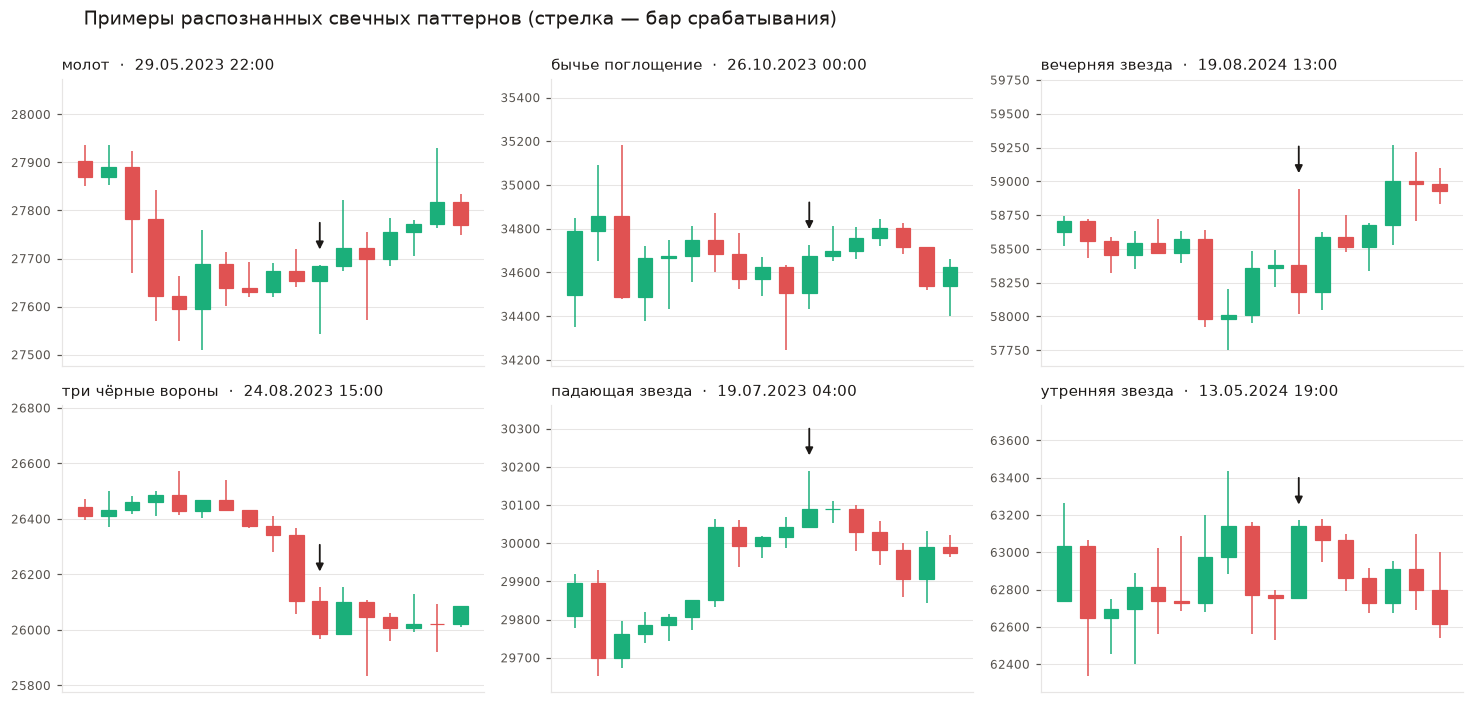

In [10]:
def plot_candles(ax, df, width=0.62):
    """Рисует японские свечи по срезу OHLC."""
    x = np.arange(len(df))
    up = df["close"].to_numpy() >= df["open"].to_numpy()
    colors = np.where(up, UP, DOWN)
    ax.vlines(x, df["low"], df["high"], color=colors, linewidth=1.0)
    for xi, (op, cl, col) in enumerate(zip(df["open"], df["close"], colors)):
        lo, height = min(op, cl), abs(cl - op)
        ax.add_patch(Rectangle((xi - width / 2, lo), width, max(height, 1e-9),
                               facecolor=col, edgecolor=col, linewidth=0.8))
    ax.set_xlim(-1, len(df))
    return x


SHOWCASE = ["cdl_hammer", "cdl_engulfing_bull", "cdl_evening_star", "cdl_three_black_crows",
            "cdl_shooting_star", "cdl_morning_star"]
fig, axes = plt.subplots(2, 3, figsize=(13.5, 6.4))
for ax, name in zip(axes.ravel(), SHOWCASE):
    hits = np.flatnonzero(cdl[name].to_numpy())
    hits = hits[(hits > 12) & (hits < len(raw) - 8)]
    i = int(hits[len(hits) // 2])                     # типичный, а не самый яркий пример
    window = raw.iloc[i - 10:i + 7].reset_index(drop=True)
    plot_candles(ax, window)
    span = window["high"].max() - window["low"].min()
    ax.annotate("", xy=(10, window["high"].iloc[10] + span * 0.06),
                xytext=(10, window["high"].iloc[10] + span * 0.22),
                arrowprops=dict(arrowstyle="-|>", color=INK, linewidth=1.2))
    ax.set_ylim(window["low"].min() - span * 0.08, window["high"].max() + span * 0.32)
    ax.set_title(f"{CANDLE_RU[name]}  ·  {raw['date'].iloc[i]:%d.%m.%Y %H:%M}",
                 color=INK, fontsize=9.5, loc="left")
    ax.set_xticks([])
    style_ax(ax)
fig.suptitle("Примеры распознанных свечных паттернов (стрелка — бар срабатывания)",
             fontsize=12.5, color=INK, x=0.06, ha="left", y=0.995)
fig.tight_layout()
plt.show()

## 5. Паттерны разворота на свинг-точках

Графические паттерны строятся не по отдельным свечам, а по **свинг-экстремумам** (фракталам):
бар считается свинг-максимумом, если его `high` — наибольший в окне ±`PIVOT_W` баров.

Здесь скрыта главная ловушка технического анализа в машинном обучении. Центрированное окно
заглядывает вперёд: чтобы узнать, что бар был вершиной, нужно дождаться `PIVOT_W` последующих
баров. Если поставить флаг «вершина» прямо на бар экстремума, модель получит знание из
будущего, ROC-AUC подскочит, а в реальной торговле стратегия развалится. Поэтому каждый
экстремум сдвигается вперёд на `PIVOT_W` баров: признак появляется **в момент подтверждения**,
то есть тогда же, когда его увидел бы трейдер.

На подтверждённых экстремумах распознаются: двойная и тройная вершина/дно, голова и плечи
(и перевёрнутая), последовательности higher high / lower low, дивергенции RSI, а также
рассчитываются расстояния до ближайших уровней поддержки и сопротивления в единицах ATR.

In [11]:
def swing_points(high, low, w=PIVOT_W):
    """Свинг-экстремумы, сдвинутые на w баров вперёд — к моменту их подтверждения."""
    is_ph = (high == high.rolling(2 * w + 1, center=True).max()) & high.notna()
    is_pl = (low == low.rolling(2 * w + 1, center=True).min()) & low.notna()
    return high.where(is_ph).shift(w), low.where(is_pl).shift(w)


def chart_patterns(high, low, close, rsi_s, atr_s, w=PIVOT_W, tol=0.02, depth=0.02):
    """Паттерны разворота по подтверждённым свинг-точкам + уровни поддержки/сопротивления."""
    ph_price, pl_price = swing_points(high, low, w)
    names = ["pat_double_top", "pat_double_bottom", "pat_triple_top", "pat_triple_bottom",
             "pat_head_shoulders", "pat_inv_head_shoulders",
             "pat_bear_divergence", "pat_bull_divergence",
             "pat_higher_high", "pat_lower_high", "pat_higher_low", "pat_lower_low"]
    out = {k: np.zeros(len(close), dtype=np.int8) for k in names}

    hi_idx, hi_val = ph_price.dropna().index.to_numpy(), ph_price.dropna().to_numpy()
    lo_idx, lo_val = pl_price.dropna().index.to_numpy(), pl_price.dropna().to_numpy()
    rsi_arr = rsi_s.to_numpy()
    hi_rsi = rsi_arr[np.maximum(hi_idx - w, 0)]        # RSI в самой точке экстремума
    lo_rsi = rsi_arr[np.maximum(lo_idx - w, 0)]

    for k in range(1, len(hi_idx)):
        i, p1, p2 = hi_idx[k], hi_val[k - 1], hi_val[k]
        out["pat_higher_high"][i] = int(p2 > p1)
        out["pat_lower_high"][i] = int(p2 < p1)
        if abs(p2 - p1) / p1 <= tol:                                  # две сопоставимые вершины
            trough = lo_val[(lo_idx > hi_idx[k - 1]) & (lo_idx < i)]  # и впадина между ними
            if len(trough) and (min(p1, p2) - trough.min()) / min(p1, p2) >= depth:
                out["pat_double_top"][i] = 1
                if k >= 2 and abs(hi_val[k - 2] - p1) / p1 <= tol:
                    out["pat_triple_top"][i] = 1
        if p2 > p1 and hi_rsi[k] < hi_rsi[k - 1] - 1:                 # цена выше, RSI ниже
            out["pat_bear_divergence"][i] = 1
        if k >= 2:
            s1, head, s2 = hi_val[k - 2], hi_val[k - 1], p2
            if head > s1 and head > s2 and abs(s1 - s2) / s1 <= 1.5 * tol:
                out["pat_head_shoulders"][i] = 1

    for k in range(1, len(lo_idx)):
        i, p1, p2 = lo_idx[k], lo_val[k - 1], lo_val[k]
        out["pat_higher_low"][i] = int(p2 > p1)
        out["pat_lower_low"][i] = int(p2 < p1)
        if abs(p2 - p1) / p1 <= tol:
            peak = hi_val[(hi_idx > lo_idx[k - 1]) & (hi_idx < i)]
            if len(peak) and (peak.max() - max(p1, p2)) / max(p1, p2) >= depth:
                out["pat_double_bottom"][i] = 1
                if k >= 2 and abs(lo_val[k - 2] - p1) / p1 <= tol:
                    out["pat_triple_bottom"][i] = 1
        if p2 < p1 and lo_rsi[k] > lo_rsi[k - 1] + 1:
            out["pat_bull_divergence"][i] = 1
        if k >= 2:
            s1, head, s2 = lo_val[k - 2], lo_val[k - 1], p2
            if head < s1 and head < s2 and abs(s1 - s2) / s1 <= 1.5 * tol:
                out["pat_inv_head_shoulders"][i] = 1

    last_ph, last_pl = ph_price.ffill(), pl_price.ffill()
    levels = pd.DataFrame({
        "dist_resistance_atr": (last_ph - close) / atr_s,
        "dist_support_atr": (close - last_pl) / atr_s,
        "pivot_range_atr": (last_ph - last_pl) / atr_s,
        "pos_in_pivot_range": (close - last_pl) / (last_ph - last_pl).replace(0, np.nan),
    }, index=close.index)
    return pd.DataFrame(out, index=close.index), levels


PATTERN_RU = {
    "key_reversal_up": "ключевой разворот вверх", "key_reversal_dn": "ключевой разворот вниз",
    "breakout_up_20": "пробой канала вверх", "breakout_dn_20": "пробой канала вниз",
    "cdl_net_score": "перевес бычьих свечей", "cdl_net_score_6": "перевес бычьих свечей за 6 ч",
    "cdl_bull_score": "число бычьих свечных сигналов", "cdl_bear_score": "число медвежьих свечных сигналов",
    "pat_double_top": "двойная вершина", "pat_double_bottom": "двойное дно",
    "pat_triple_top": "тройная вершина", "pat_triple_bottom": "тройное дно",
    "pat_head_shoulders": "голова и плечи", "pat_inv_head_shoulders": "перевёрнутые голова и плечи",
    "pat_bear_divergence": "медвежья дивергенция RSI", "pat_bull_divergence": "бычья дивергенция RSI",
    "pat_higher_high": "higher high", "pat_lower_high": "lower high",
    "pat_higher_low": "higher low", "pat_lower_low": "lower low",
    "pat_bull_flag": "бычий флаг", "pat_bear_flag": "медвежий флаг", "pat_pennant": "вымпел",
}

rsi14_raw = rsi(raw["close"], 14)
chart_pat, sr_levels = chart_patterns(raw["high"], raw["low"], raw["close"], rsi14_raw, atr14)
display(pd.DataFrame({
    "паттерн": [PATTERN_RU[c] for c in chart_pat.columns],
    "срабатываний": chart_pat.sum().to_numpy(),
    "частота, %": (chart_pat.mean() * 100).round(2).to_numpy(),
}, index=chart_pat.columns).sort_values("срабатываний", ascending=False))

,паттерн,срабатываний,"частота, %"
pat_higher_low,higher low,1696,3.49
pat_lower_high,lower high,1628,3.35
pat_higher_high,higher high,1553,3.19
pat_lower_low,lower low,1474,3.03
pat_double_top,двойная вершина,722,1.48
pat_head_shoulders,голова и плечи,705,1.45
pat_inv_head_shoulders,перевёрнутые голова и плечи,690,1.42
pat_double_bottom,двойное дно,682,1.40
pat_triple_top,тройная вершина,483,0.99
pat_triple_bottom,тройное дно,459,0.94


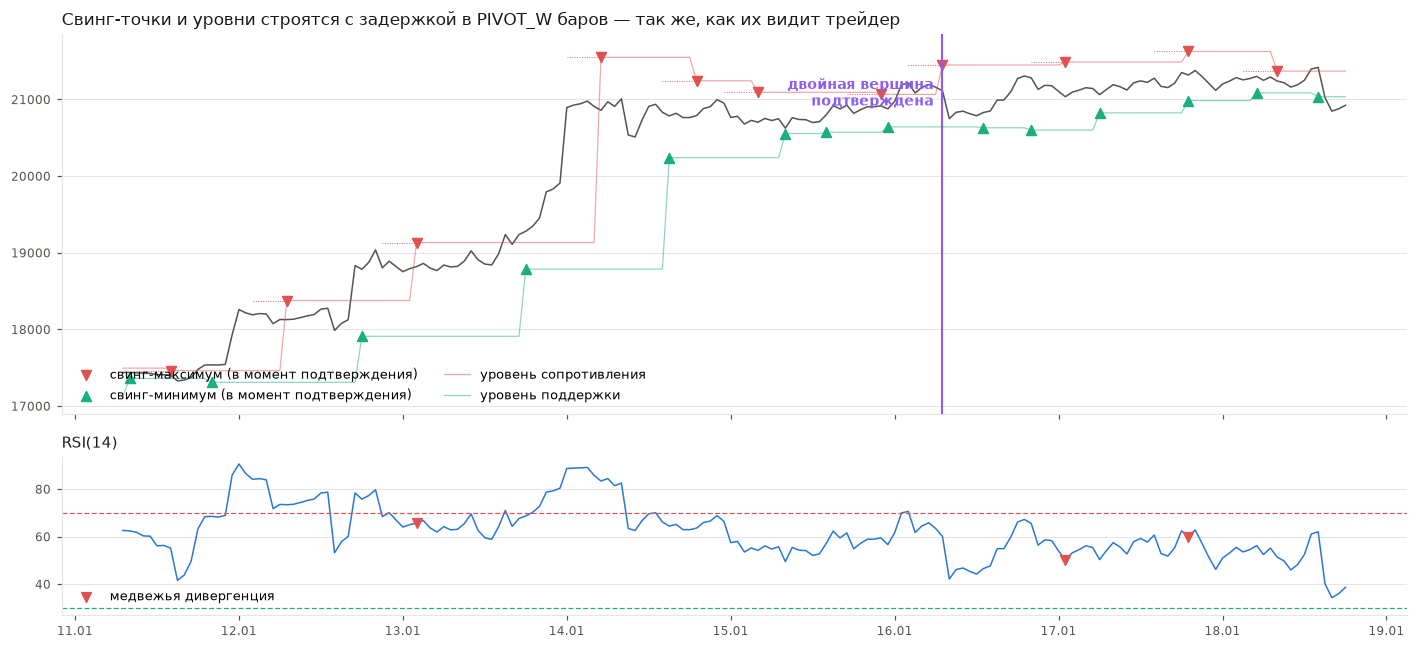

In [12]:
# Иллюстрация: свинг-точки, уровни и подтверждённая двойная вершина.
ph_p, pl_p = swing_points(raw["high"], raw["low"])
dt_hits = np.flatnonzero(chart_pat["pat_double_top"].to_numpy())
i = int(dt_hits[len(dt_hits) // 2])
seg = raw.iloc[i - 120:i + 60]
x = seg["date"]

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True,
                              gridspec_kw={"height_ratios": [2.4, 1]})
ax.plot(x, seg["close"], color=INK_MUTED, linewidth=1.0, zorder=1)
conf_h = seg.index[ph_p.loc[seg.index].notna()]
conf_l = seg.index[pl_p.loc[seg.index].notna()]
ax.scatter(raw.loc[conf_h, "date"], ph_p.loc[conf_h], marker="v", s=42, color=DOWN,
           zorder=3, label="свинг-максимум (в момент подтверждения)")
ax.scatter(raw.loc[conf_l, "date"], pl_p.loc[conf_l], marker="^", s=42, color=UP,
           zorder=3, label="свинг-минимум (в момент подтверждения)")
for j in conf_h:                                        # поводок от подтверждения к самому экстремуму
    ax.plot([raw["date"].iloc[j - PIVOT_W], raw["date"].iloc[j]],
            [raw["high"].iloc[j - PIVOT_W], ph_p.loc[j]], color=DOWN, linewidth=0.6,
            linestyle=":", zorder=2)
ax.axvline(raw["date"].iloc[i], color=COLORS["Ensemble"], linewidth=1.4, zorder=4)
ax.annotate("двойная вершина\nподтверждена", xy=(raw["date"].iloc[i], seg["close"].max()),
            xytext=(-6, -6), textcoords="offset points", ha="right", va="top",
            fontsize=9, color=COLORS["Ensemble"], fontweight="bold")
ax.plot(x, sr_levels.loc[seg.index, "dist_resistance_atr"] * atr14.loc[seg.index] + seg["close"],
        color=DOWN, linewidth=0.8, alpha=0.5, label="уровень сопротивления")
ax.plot(x, seg["close"] - sr_levels.loc[seg.index, "dist_support_atr"] * atr14.loc[seg.index],
        color=UP, linewidth=0.8, alpha=0.5, label="уровень поддержки")
ax.set_title("Свинг-точки и уровни строятся с задержкой в PIVOT_W баров — так же, как их видит трейдер",
             color=INK, loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=8.5, loc="lower left", ncol=2)
style_ax(ax)

ax2.plot(x, rsi14_raw.loc[seg.index], color=COLORS["LogisticRegression"], linewidth=1.0)
ax2.axhline(70, color=DOWN, linewidth=0.8, linestyle=(0, (4, 2)))
ax2.axhline(30, color=UP, linewidth=0.8, linestyle=(0, (4, 2)))
div = seg.index[chart_pat.loc[seg.index, "pat_bear_divergence"] > 0]
ax2.scatter(raw.loc[div, "date"], rsi14_raw.loc[div], s=40, color=DOWN, marker="v", zorder=3,
            label="медвежья дивергенция")
ax2.set_title("RSI(14)", color=INK, loc="left", fontsize=10)
ax2.legend(frameon=False, fontsize=8.5, loc="lower left")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax2)
fig.tight_layout()
plt.show()

## 6. Паттерны продолжения

Разворотные паттерны отвечают на вопрос «не закончился ли тренд». Паттерны продолжения —
на обратный: «тренд взял паузу или всё-таки развернулся». Реализованы:

- **пробой канала Дончиана** (`breakout_up/dn`) — закрытие выше максимума / ниже минимума
  предыдущих N баров; классический сигнал продолжения тренда;
- **флаг и вымпел** — сильный импульс (движение больше 2 ATR за 12 баров), после которого
  диапазон сжимается, а объём падает; это консолидация внутри тренда, а не разворот;
- **сжатие волатильности** (`bb_squeeze`, `ttm_squeeze`) — ширина полос Боллинджера в нижнем
  квинтиле недельного распределения либо полосы внутри канала Кельтнера; за сжатием обычно
  следует направленное движение;
- **коэффициент эффективности Кауфмана** — доля направленного движения в общем пути цены;
- **серии** — сколько баров подряд цена держится выше EMA20, длина серии внутренних баров,
  длина серии однонаправленных баров.

## 7. Сборка признаков

Все признаки собираются в один датафрейм и группируются по смыслу.

In [13]:
MA_WINDOWS = [5, 10, 20, 50, 100, 200]
RET_HORIZONS = [1, 2, 3, 6, 12, 24, 48, 72, 168]


def running_streak(sign_series):
    """Длина текущей серии одинаковых знаков: +n — n баров подряд вверх, -n — вниз."""
    s = pd.Series(sign_series).fillna(0).to_numpy()
    out = np.zeros(len(s))
    for i in range(1, len(s)):
        out[i] = out[i - 1] + s[i] if s[i] == s[i - 1] and s[i] != 0 else s[i]
    return pd.Series(out, index=pd.Series(sign_series).index)


def bars_since(flag, cap=500):
    """Сколько баров прошло с последнего срабатывания флага."""
    f = pd.Series(flag).fillna(False).to_numpy().astype(bool)
    out, last = np.empty(len(f)), -1
    for i in range(len(f)):
        if f[i]:
            last = i
        out[i] = (i - last) if last >= 0 else np.nan
    return pd.Series(np.minimum(out, cap), index=pd.Series(flag).index)


def build_ta_features(df, n_lags=N_LAGS):
    """Полная матрица признаков технического анализа. Возвращает (признаки, группы)."""
    o_, h_, l_, c_, v_ = (df[x] for x in OHLCV)
    X, groups = {}, {}

    def add(group, cols):
        groups.setdefault(group, []).extend(cols)
        X.update(cols)

    atr_s = atr(h_, l_, c_, 14)
    natr = atr_s / c_
    ret_1 = c_.pct_change()
    logret = np.log(c_).diff()

    # ── доходности и лаги ───────────────────────────────────────────────────
    cols = {}
    for k in RET_HORIZONS:
        cols[f"ret_{k}"] = c_.pct_change(k)
        cols[f"ret_{k}_atr"] = (c_ / c_.shift(k) - 1) / natr.replace(0, np.nan)   # ход в ATR
    for k in range(n_lags):
        cols[f"ret_lag_{k}"] = ret_1.shift(k)
    cols["logret_skew_24"] = logret.rolling(24).skew()
    cols["logret_kurt_24"] = logret.rolling(24).kurt()
    cols["up_bars_frac_24"] = (ret_1 > 0).rolling(24).mean()
    cols["ret_streak"] = running_streak(np.sign(ret_1.fillna(0)))
    add("доходности", cols)

    # ── скользящие средние ──────────────────────────────────────────────────
    cols, sma, ema = {}, {}, {}
    for w in MA_WINDOWS:
        sma[w] = c_.rolling(w).mean()
        ema[w] = c_.ewm(span=w, adjust=False).mean()
        cols[f"close_sma{w}_ratio"] = c_ / sma[w] - 1
        cols[f"close_ema{w}_ratio"] = c_ / ema[w] - 1
        cols[f"sma{w}_slope"] = sma[w].pct_change(max(3, w // 4))
        cols[f"close_sma{w}_atr"] = (c_ - sma[w]) / atr_s          # удалённость от MA в ATR
    for fast, slow in [(5, 20), (10, 50), (20, 50), (50, 200)]:
        spread = sma[fast] / sma[slow] - 1
        above = (spread > 0).astype(np.int8)
        up_cross = ((above == 1) & (above.shift(1) == 0)).astype(np.int8)
        dn_cross = ((above == 0) & (above.shift(1) == 1)).astype(np.int8)
        cols[f"ma_spread_{fast}_{slow}"] = spread
        cols[f"ma_above_{fast}_{slow}"] = above
        cols[f"ma_cross_up_{fast}_{slow}"] = up_cross               # «золотой крест»
        cols[f"ma_cross_dn_{fast}_{slow}"] = dn_cross               # «мёртвый крест»
        cols[f"bars_since_cross_{fast}_{slow}"] = bars_since((up_cross + dn_cross) > 0)
    ribbon = sum((sma[a] > sma[b]).astype(int) for a, b in zip(MA_WINDOWS[:-1], MA_WINDOWS[1:]))
    cols["ma_ribbon_score"] = ribbon / (len(MA_WINDOWS) - 1)        # упорядоченность «ленты» MA
    cols["price_above_all_ma"] = np.minimum.reduce([(c_ > sma[w]).to_numpy() for w in MA_WINDOWS]).astype(np.int8)
    cols["price_below_all_ma"] = np.minimum.reduce([(c_ < sma[w]).to_numpy() for w in MA_WINDOWS]).astype(np.int8)
    add("скользящие средние", cols)

    # ── осцилляторы импульса ────────────────────────────────────────────────
    cols = {}
    for n in (7, 14, 28):
        r = rsi(c_, n)
        cols[f"rsi_{n}"], cols[f"rsi_{n}_slope"] = r, r.diff(3)
    r14 = cols["rsi_14"]
    cols["rsi_overbought"] = (r14 > 70).astype(np.int8)
    cols["rsi_oversold"] = (r14 < 30).astype(np.int8)
    cols["rsi_cross_50_up"] = ((r14 > 50) & (r14.shift(1) <= 50)).astype(np.int8)
    cols["rsi_cross_50_dn"] = ((r14 < 50) & (r14.shift(1) >= 50)).astype(np.int8)
    k_, d_ = stochastic(h_, l_, c_, 14, 3)
    cols["stoch_k"], cols["stoch_d"], cols["stoch_diff"] = k_, d_, k_ - d_
    cols["williams_r"] = k_ - 100
    line, sig, hist = macd(c_)
    cols["macd"], cols["macd_signal"], cols["macd_hist"] = line / c_, sig / c_, hist / c_
    cols["macd_hist_slope"] = (hist / c_).diff(3)
    cols["macd_cross_up"] = ((hist > 0) & (hist.shift(1) <= 0)).astype(np.int8)
    cols["macd_cross_dn"] = ((hist < 0) & (hist.shift(1) >= 0)).astype(np.int8)
    adx_s, pdi, mdi = adx(h_, l_, c_, 14)
    cols["adx"], cols["di_plus"], cols["di_minus"] = adx_s, pdi, mdi
    cols["di_diff"], cols["adx_slope"] = pdi - mdi, adx_s.diff(3)
    cols["adx_strong_trend"] = (adx_s > 25).astype(np.int8)
    cols["cci_20"] = cci(h_, l_, c_, 20)
    au, ad = aroon(h_, l_, 25)
    cols["aroon_up"], cols["aroon_down"], cols["aroon_osc"] = au, ad, au - ad
    cols["mom_roc_12"] = c_.pct_change(12)
    cols["ultimate_bias"] = (c_ - (h_.rolling(24).max() + l_.rolling(24).min()) / 2) / atr_s
    add("осцилляторы", cols)

    # ── волатильность ───────────────────────────────────────────────────────
    cols = {}
    cols["atr_14"] = natr
    cols["atr_ratio_short_long"] = atr(h_, l_, c_, 7) / atr_s.replace(0, np.nan)
    cols["tr_atr"] = true_range(h_, l_, c_) / atr_s.replace(0, np.nan)
    for n in (24, 72, 168):
        cols[f"vol_{n}"] = logret.rolling(n).std(ddof=0)
    cols["vol_regime"] = cols["vol_24"] / cols["vol_168"].replace(0, np.nan)
    cols["vol_of_vol"] = cols["vol_24"].rolling(72).std(ddof=0) / cols["vol_24"].replace(0, np.nan)
    cols["parkinson_24"] = np.sqrt((np.log(h_ / l_) ** 2).rolling(24).mean() / (4 * np.log(2)))
    cols["garman_klass_24"] = np.sqrt((0.5 * np.log(h_ / l_) ** 2
                                       - (2 * np.log(2) - 1) * np.log(c_ / o_) ** 2)
                                      .rolling(24).mean().clip(lower=0))
    bb_mid, bb_std = c_.rolling(20).mean(), c_.rolling(20).std(ddof=0)
    cols["bb_pctb"] = (c_ - (bb_mid - 2 * bb_std)) / (4 * bb_std).replace(0, np.nan)
    cols["bb_width"] = (4 * bb_std) / bb_mid
    cols["bb_squeeze"] = (cols["bb_width"] < cols["bb_width"].rolling(168).quantile(0.20)).astype(np.int8)
    kc_mid = c_.ewm(span=20, adjust=False).mean()
    cols["kc_pos"] = (c_ - kc_mid) / (2 * atr_s).replace(0, np.nan)
    cols["ttm_squeeze"] = ((bb_mid + 2 * bb_std < kc_mid + 2 * atr_s) &
                           (bb_mid - 2 * bb_std > kc_mid - 2 * atr_s)).astype(np.int8)
    add("волатильность", cols)

    # ── объём ───────────────────────────────────────────────────────────────
    cols = {}
    logv_ = np.log1p(v_)
    cols["vol_z_24"], cols["vol_z_168"] = zscore(logv_, 24), zscore(logv_, 168)
    cols["vol_ratio_sma"] = v_ / v_.rolling(24).mean().replace(0, np.nan)
    cols["vol_change"] = logv_.diff()
    obv_s = obv(c_, v_)
    cols["obv_z"] = zscore(obv_s, 168)
    cols["obv_slope"] = obv_s.diff(24) / v_.rolling(24).sum().replace(0, np.nan)
    cols["mfi_14"] = mfi(h_, l_, c_, v_, 14)
    cols["cmf_20"] = cmf(h_, l_, c_, v_, 20)
    vwap = (((h_ + l_ + c_) / 3) * v_).rolling(24).sum() / v_.rolling(24).sum().replace(0, np.nan)
    cols["vwap_dev"] = c_ / vwap - 1
    cols["force_index"] = wilder(c_.diff() * v_, 13) / (atr_s * v_.rolling(24).mean()).replace(0, np.nan)
    cols["vol_price_corr_24"] = logret.rolling(24).corr(logv_.diff())
    add("объём", cols)

    # ── свечи: геометрия и паттерны ─────────────────────────────────────────
    cdl_df, anat = candlestick_patterns(o_, h_, l_, c_, atr_s)
    cols = {
        "body_frac": anat["body_frac"], "upper_frac": anat["upper_frac"],
        "lower_frac": anat["lower_frac"], "clv": anat["clv"],
        "range_atr": anat["rng"] / atr_s.replace(0, np.nan),
        "body_atr": anat["body"] / atr_s.replace(0, np.nan),
        "gap_open": o_ / c_.shift(1) - 1,
        "shadow_imbalance": (anat["upper"] - anat["lower"]) / anat["rng"],
    }
    cols.update({name: cdl_df[name] for name in cdl_df.columns})
    bull_cnt, bear_cnt = cdl_df[CANDLE_BULL].sum(axis=1), cdl_df[CANDLE_BEAR].sum(axis=1)
    cols["cdl_bull_score"], cols["cdl_bear_score"] = bull_cnt, bear_cnt
    cols["cdl_net_score"] = bull_cnt - bear_cnt
    cols["cdl_net_score_6"] = (bull_cnt - bear_cnt).rolling(6).sum()
    add("свечные паттерны", cols)

    # ── паттерны разворота ──────────────────────────────────────────────────
    pat_df, lvl = chart_patterns(h_, l_, c_, X["rsi_14"], atr_s)
    cols = {}
    for name in pat_df.columns:
        cols[name] = pat_df[name]
        cols[f"{name}_24"] = pat_df[name].rolling(24).max()      # паттерн «действует» ещё сутки
    cols.update({name: lvl[name] for name in lvl.columns})
    cols["dist_high_168_atr"] = (h_.rolling(168).max() - c_) / atr_s
    cols["dist_low_168_atr"] = (c_ - l_.rolling(168).min()) / atr_s
    cols["new_high_168"] = (c_ >= c_.rolling(168).max()).astype(np.int8)
    cols["new_low_168"] = (c_ <= c_.rolling(168).min()).astype(np.int8)
    cols["key_reversal_up"] = ((l_ < l_.shift(1).rolling(24).min()) & (c_ > c_.shift(1))).astype(np.int8)
    cols["key_reversal_dn"] = ((h_ > h_.shift(1).rolling(24).max()) & (c_ < c_.shift(1))).astype(np.int8)
    add("паттерны разворота", cols)

    # ── паттерны продолжения ────────────────────────────────────────────────
    cols = {}
    for n in (20, 55):
        dh, dl = h_.rolling(n).max(), l_.rolling(n).min()
        cols[f"donchian_pos_{n}"] = (c_ - dl) / (dh - dl).replace(0, np.nan)
        cols[f"donchian_width_{n}"] = (dh - dl) / atr_s
        cols[f"breakout_up_{n}"] = (c_ > dh.shift(1)).astype(np.int8)
        cols[f"breakout_dn_{n}"] = (c_ < dl.shift(1)).astype(np.int8)
    cols["er_20"], cols["er_72"] = efficiency_ratio(c_, 20), efficiency_ratio(c_, 72)
    impulse_up = (c_.shift(6) / c_.shift(18) - 1) > 2 * natr.shift(6)
    impulse_dn = (c_.shift(6) / c_.shift(18) - 1) < -2 * natr.shift(6)
    consolidation = (((h_.rolling(6).max() - l_.rolling(6).min()) / atr_s < 2.0) &
                     (v_.rolling(6).mean() < v_.rolling(24).mean()))
    cols["pat_bull_flag"] = (impulse_up & consolidation).astype(np.int8)
    cols["pat_bear_flag"] = (impulse_dn & consolidation).astype(np.int8)
    cols["pat_pennant"] = (consolidation & (X["bb_squeeze"] == 1)).astype(np.int8)
    cols["range_contraction"] = ((h_.rolling(6).max() - l_.rolling(6).min()) /
                                 (h_.rolling(24).max() - l_.rolling(24).min()).replace(0, np.nan))
    cols["inside_bar_streak"] = running_streak(cdl_df["cdl_inside_bar"].astype(int))
    cols["above_ema20_streak"] = running_streak((c_ > ema[20]).astype(int))
    cols["trend_continuation"] = (((X["adx"] > 25) & (X["adx_slope"] > 0) &
                                   (X["di_diff"].abs() > 5)).astype(np.int8) * np.sign(X["di_diff"]))
    add("паттерны продолжения", cols)

    # ── аномальность бара (раздел 2) ────────────────────────────────────────
    cols = {
        "anom_ret_z": robust_z(ret_1, ANOM_WIN),
        "anom_vol_z": robust_z(np.log1p(v_), ANOM_WIN),
        "anom_tr_z": robust_z(true_range(h_, l_, c_), ANOM_WIN),
    }
    cols["anom_ret_outlier"] = (cols["anom_ret_z"].abs() > OUTLIER_Z).astype(np.int8)
    cols["anom_vol_outlier"] = (cols["anom_vol_z"].abs() > OUTLIER_Z).astype(np.int8)
    cols["anom_any"] = ((cols["anom_ret_outlier"] + cols["anom_vol_outlier"]) > 0).astype(np.int8)
    cols["anom_count_24"] = cols["anom_any"].rolling(24).sum()
    cols["anom_bars_since"] = bars_since(cols["anom_any"] > 0)
    add("аномалии", cols)

    # ── календарь ───────────────────────────────────────────────────────────
    hour, dow = df["date"].dt.hour, df["date"].dt.dayofweek
    add("календарь", {
        "hour_sin": np.sin(2 * np.pi * hour / 24), "hour_cos": np.cos(2 * np.pi * hour / 24),
        "dow_sin": np.sin(2 * np.pi * dow / 7), "dow_cos": np.cos(2 * np.pi * dow / 7),
        "is_weekend": (dow >= 5).astype(np.int8),
    })

    return pd.concat([df, pd.DataFrame(X, index=df.index)], axis=1), groups


feat, FEATURE_GROUPS = build_ta_features(raw)
feature_cols = [c for g in FEATURE_GROUPS.values() for c in g]
assert len(feature_cols) == len(set(feature_cols)), "дублирующиеся имена признаков"

group_table = pd.DataFrame({
    "признаков": {g: len(cols) for g, cols in FEATURE_GROUPS.items()},
    "примеры": {g: ", ".join(cols[:3]) + (" …" if len(cols) > 3 else "")
                for g, cols in FEATURE_GROUPS.items()},
}).rename_axis("группа")
print(f"Всего признаков: {len(feature_cols)} (в ДЗ №2 было 24 лага доходности)")
display(group_table)

Всего признаков: 246 (в ДЗ №2 было 24 лага доходности)


,признаков,примеры
группа,,
доходности,34,"ret_1, ret_1_atr, ret_2 …"
скользящие средние,47,"close_sma5_ratio, close_ema5_ratio, sma5_slope …"
осцилляторы,32,"rsi_7, rsi_7_slope, rsi_14 …"
волатильность,15,"atr_14, atr_ratio_short_long, tr_atr …"
объём,11,"vol_z_24, vol_z_168, vol_ratio_sma …"
свечные паттерны,43,"body_frac, upper_frac, lower_frac …"
паттерны разворота,34,"pat_double_top, pat_double_top_24, pat_double_..."
паттерны продолжения,17,"donchian_pos_20, donchian_width_20, breakout_u..."
аномалии,8,"anom_ret_z, anom_vol_z, anom_tr_z …"


In [14]:
# Целевая переменная и подготовка датафрейма.
close = feat["close"]
feat["target"] = (close.shift(-HORIZON) > close).astype("float")   # направление через HORIZON баров
feat["fwd_ret"] = close.shift(-1) / close - 1                      # доходность бара t -> t+1

# бесконечности возникают при делении на нулевую волатильность — трактуем как пропуск
feat[feature_cols] = feat[feature_cols].replace([np.inf, -np.inf], np.nan)

# «Прогрев»: первые бары обрезаются, потому что окно SMA(200) ещё не заполнено.
# Строки в середине ряда НЕ удаляются — непрерывность ряда важнее пары пропусков,
# редкие внутренние NaN (например, MFI при нулевом знаменателе) переносятся с предыдущего бара.
warmup = max(feat[c].first_valid_index() for c in feature_cols)
interior_nan = int(feat[feature_cols].iloc[warmup:].isna().sum().sum())
feat = feat.iloc[warmup:].reset_index(drop=True)
feat[feature_cols] = feat[feature_cols].ffill().fillna(0)
feat = feat.dropna(subset=["target", "fwd_ret"]).reset_index(drop=True)
feat["target"] = feat["target"].astype(int)

print(f"Прогрев: отброшено первых {warmup} баров; заполнено {interior_nan} внутренних пропусков")
print(f"Итоговая матрица: {len(feat)} наблюдений × {len(feature_cols)} признаков")
print(f"Период: {feat['date'].min()} — {feat['date'].max()}")
print(f"Баланс классов: {feat['target'].value_counts(normalize=True).round(3).to_dict()}")

Прогрев: отброшено первых 680 баров; заполнено 11 внутренних пропусков
Итоговая матрица: 47944 наблюдений × 246 признаков
Период: 2021-01-29 08:00:00 — 2026-07-19 23:00:00
Баланс классов: {1: 0.504, 0: 0.496}


### 7.1 Проверка на утечку данных

Обрезаем ряд на произвольном баре, пересчитываем все признаки на обрезанных
данных и сравниваем с признаками, посчитанными на полном ряде. Если ни одна функция не
использует будущее, значения обязаны совпасть.

In [15]:
CUT = int(len(raw) * 0.6)
truncated, _ = build_ta_features(raw.iloc[:CUT].reset_index(drop=True))
full_slice = build_ta_features(raw)[0].iloc[:CUT].reset_index(drop=True)

check_from = 500                                    # пропускаем прогрев индикаторов
SENTINEL = -9.876543e12                             # чтобы NaN не «замаскировал» расхождение
a = truncated[feature_cols].iloc[check_from:CUT - 1].fillna(SENTINEL)
b = full_slice[feature_cols].iloc[check_from:CUT - 1].fillna(SENTINEL)
diff = (a - b).abs().max()
bad = diff[diff > 1e-9].sort_values(ascending=False)

print(f"Ряд обрезан на баре {CUT} ({raw['date'].iloc[CUT]}), признаки пересчитаны заново.")
print(f"Сравнивается {len(a)} строк × {len(feature_cols)} признаков.")
if len(bad) == 0:
    print("OK: все признаки совпали — ни один из них не использует данные из будущего.")
else:
    display(bad.head(20))
    raise AssertionError(f"{len(bad)} признаков зависят от будущего")

# сдвиг признаков относительно последнего бара: у свинг-паттернов он ожидаемо равен PIVOT_W
last_pivot = swing_points(raw["high"], raw["low"])[0].last_valid_index()
print(f"\nПоследний подтверждённый свинг-максимум относится к бару {last_pivot} из {len(raw) - 1}: "
      f"задержка подтверждения {len(raw) - 1 - last_pivot} баров при PIVOT_W = {PIVOT_W}.")

Ряд обрезан на баре 29175 (2024-04-30 15:00:00), признаки пересчитаны заново.
Сравнивается 28674 строк × 246 признаков.
OK: все признаки совпали — ни один из них не использует данные из будущего.

Последний подтверждённый свинг-максимум относится к бару 48607 из 48624: задержка подтверждения 17 баров при PIVOT_W = 5.


## 8. Разбиение на train / test / validation

Разбиваем строго по времени, без перемешивания:

- **train** (70%) — обучение;
- **test** (15%) — вместе с train участвует в подборе гиперпараметров;
- **validation** (15%) — отложенная выборка, используется ровно один раз в конце;
- **dev** = train + test — внутри него идёт кросс-валидация временных рядов.

Между выборками выдерживается разрыв, чтобы последние бары обучающей части не знали о начале следующей.

In [16]:
n = len(feat)
train_end = int(n * TRAIN_END)
test_end = int(n * TEST_END)

train_df = feat.iloc[:train_end - EMBARGO].reset_index(drop=True)
test_df = feat.iloc[train_end:test_end - EMBARGO].reset_index(drop=True)
val_df = feat.iloc[test_end:].reset_index(drop=True)
dev_df = feat.iloc[:test_end - EMBARGO].reset_index(drop=True)

for name, part in (("train", train_df), ("test", test_df), ("validation", val_df)):
    print(f"{name:11s}: {len(part):5d} строк | {part['date'].min()} — {part['date'].max()}")

gap_tr_te = (test_df["date"].min() - train_df["date"].max()) / pd.Timedelta(hours=1)
gap_te_val = (val_df["date"].min() - test_df["date"].max()) / pd.Timedelta(hours=1)
print(f"\nразрыв train->test: {gap_tr_te:.0f} ч, test->validation: {gap_te_val:.0f} ч "
      f"(нужно > {HORIZON} ч — на длину метки)")
assert gap_tr_te > HORIZON and gap_te_val > HORIZON, "выборки перекрываются по периоду метки"

bh_val_return = float((1 + val_df["fwd_ret"]).prod() - 1)
print(f"Buy & hold на валидации: {bh_val_return:+.1%} — период {'падающий' if bh_val_return < 0 else 'растущий'}")

train      : 33559 строк | 2021-01-29 08:00:00 — 2024-11-27 14:00:00
test       :  7191 строк | 2024-11-27 16:00:00 — 2025-09-23 06:00:00
validation :  7192 строк | 2025-09-23 08:00:00 — 2026-07-19 23:00:00

разрыв train->test: 2 ч, test->validation: 2 ч (нужно > 1 ч — на длину метки)
Buy & hold на валидации: -42.9% — период падающий


## 9. Бэктест и стоимостно-осознанный торговый слой

In [17]:
def backtest(dates, fwd_ret, position, fee_rate=FEE_RATE):
    """Бэктест непрерывной позиции.

    position — доля капитала в позиции от -1 (полный short) до +1 (полный long), принятая
    в момент t по информации, известной к t, и применённая к доходности бара (t -> t+1).
    Комиссия начисляется с оборота |Δposition|: переворот long <-> short стоит 2 * fee_rate.

    Доходность считается и gross (без издержек), и net (с издержками): без этого разделения
    нельзя отличить «у модели нет предсказательной силы» от «edge есть, но его съедают издержки».
    """
    dates = pd.Series(dates).reset_index(drop=True)
    fwd_ret = np.asarray(fwd_ret, dtype=float)
    position = np.asarray(position, dtype=float)

    prev = np.roll(position, 1)
    prev[0] = 0.0                                   # до первой сделки капитал вне рынка
    turnover = np.abs(position - prev)

    gross_ret = position * fwd_ret
    fees = fee_rate * turnover
    strat_ret = gross_ret - fees

    equity = (1 + strat_ret).cumprod()
    equity_gross = (1 + gross_ret).cumprod()
    drawdown = equity / np.maximum.accumulate(equity) - 1

    n_periods = len(strat_ret)
    if n_periods == 0:
        raise ValueError("backtest получил пустую выборку")
    total_return = float(equity[-1] - 1)
    vol = strat_ret.std(ddof=0)
    gross_vol = gross_ret.std(ddof=0)

    curve = pd.DataFrame({"date": dates, "position": position, "strategy_return": strat_ret,
                          "equity": equity, "equity_gross": equity_gross, "drawdown": drawdown})
    metrics = {
        "total_return": total_return,                                   # net, с издержками
        "gross_return": float(equity_gross[-1] - 1),                    # edge модели
        "fee_drag": float(fees.sum()),                                  # издержки в долях капитала
        "annualized_return": float((1 + total_return) ** (PERIODS_PER_YEAR / n_periods) - 1),
        "sharpe": float(strat_ret.mean() / vol * np.sqrt(PERIODS_PER_YEAR)) if vol > 0 else 0.0,
        "gross_sharpe": float(gross_ret.mean() / gross_vol * np.sqrt(PERIODS_PER_YEAR)) if gross_vol > 0 else 0.0,
        "max_drawdown": float(drawdown.min()),
        "n_trades": int((turnover > TRADE_EPS).sum()),
        "turnover_units": float(turnover.sum()),
        "time_in_market": float((np.abs(position) > TRADE_EPS).mean()),
        "avg_abs_position": float(np.abs(position).mean()),              # фактическая экспозиция
        "avg_position": float(position.mean()),                          # смещение в long/short
        "profitable_bars": float((strat_ret > 0).mean()),
    }
    return curve, metrics


def positions_from_proba(proba, mode="hold", q=0.1, scale=10.0, span=1, rebalance=1, ref=None):
    """Перевод вероятности роста в позицию.

    mode:
      always    — всегда в рынке ±1 (правило из ДЗ №2);
      flat      — вне рынка в зоне неопределённости;
      hold      — в зоне неопределённости удерживается предыдущая позиция (гистерезис);
      ramp      — размер позиции растёт линейно от порога до экстремума вероятности;
      long_flat — только long или вне рынка (шорт запрещён);
      scaled    — непрерывный размер позиции, пропорциональный уверенности.

    span      — окно экспоненциального сглаживания вероятности (гасит однобаровый шум);
    rebalance — позиция пересматривается раз в k баров;
    q         — доля баров с каждой стороны, попадающая в «уверенную» зону; пороги берутся как
                квантили распределения вероятностей, что устойчиво к калибровке модели;
    ref       — распределение вероятностей, по которому считаются пороги (на валидации это
                распределение с dev-выборки: пороги не подбираются по будущим данным).
    """
    p = np.asarray(proba, dtype=float)
    if span > 1:
        p = pd.Series(p).ewm(span=span, adjust=False).mean().to_numpy()
    src = p if ref is None else np.asarray(ref, dtype=float)

    if mode == "always":
        pos = np.where(p >= 0.5, 1.0, -1.0)
    elif mode in ("hold", "flat"):
        hi, lo = np.quantile(src, 1 - q), np.quantile(src, q)
        sig = np.where(p >= hi, 1.0, np.where(p <= lo, -1.0, np.nan))
        pos = pd.Series(sig).ffill().fillna(0.0).to_numpy() if mode == "hold" else np.nan_to_num(sig)
    elif mode == "long_flat":
        pos = (p >= np.quantile(src, 1 - q)).astype(float)
    elif mode == "ramp":
        hi, lo = np.quantile(src, 1 - q), np.quantile(src, q)
        up = np.clip((p - hi) / max(np.quantile(src, 0.999) - hi, 1e-6), 0, 1)
        dn = np.clip((lo - p) / max(lo - np.quantile(src, 0.001), 1e-6), 0, 1)
        pos = up - dn
    elif mode == "scaled":
        pos = np.clip((p - 0.5) * scale, -1.0, 1.0)
    else:
        raise ValueError(f"неизвестный режим сигнала: {mode}")

    if rebalance > 1:
        keep = (np.arange(len(pos)) % rebalance) == 0
        pos = pd.Series(np.where(keep, pos, np.nan)).ffill().fillna(0.0).to_numpy()
    return pos


# сетка торгового слоя: перебирается при подборе гиперпараметров
SIGNAL_GRID = ([{"mode": "always"}] +
               [{"mode": m, "q": q} for m in ("hold", "flat", "ramp", "long_flat")
                for q in (0.02, 0.05, 0.10, 0.20, 0.35)] +
               [{"mode": "scaled", "scale": s} for s in (4, 10, 25)])
SPAN_GRID = (1, 4, 12, 24)
REBALANCE_GRID = (1, 6, 24)


def tune_signal_layer(proba, dates, fwd_ret, fee_rate=FEE_RATE):
    """Перебор параметров торгового слоя по чистому (net) коэффициенту Шарпа.

    Максимизировать один только Sharpe нельзя — у этой задачи есть вырожденный оптимум.
    Стратегия, которая держит крошечную почти постоянную позицию, не платит комиссий и
    показывает прекрасный Sharpe при нулевой полезности: это замаскированный buy & hold с
    плечом 0.07, а не торговая система. Ровно в этот угол и уходит оптимизатор, если его не
    ограничить. Поэтому конфигурация обязана:

    1. давать оборот не меньше MIN_TURNOVER_PER_YEAR единиц капитала в год — то есть
       действительно менять решение, а не «пересиживать»;
    2. держать средний размер позиции не меньше MIN_AVG_EXPOSURE капитала — то есть
       действительно рисковать деньгами;
    3. быть прибыльной хотя бы в MIN_POSITIVE_BLOCKS из N_BLOCKS подпериодов — защита от
       результата, который держится на одной удачной сделке.

    Возвращает (параметры, таблица, признак того, что допустимая конфигурация найдена).
    """
    rows = []
    for span in SPAN_GRID:
        for reb in REBALANCE_GRID:
            for prm in SIGNAL_GRID:
                pos = positions_from_proba(proba, span=span, rebalance=reb, **prm)
                curve, m = backtest(dates, fwd_ret, pos, fee_rate)
                blocks = np.array_split(curve["strategy_return"].to_numpy(), N_BLOCKS)
                block_sharpe = [float(b.mean() / b.std(ddof=0) * np.sqrt(PERIODS_PER_YEAR))
                                if b.std(ddof=0) > 0 else 0.0 for b in blocks]
                rows.append({**prm, "span": span, "rebalance": reb, "sharpe": m["sharpe"],
                             "net": m["total_return"], "gross": m["gross_return"],
                             "turnover": m["turnover_units"], "n_trades": m["n_trades"],
                             "time_in_market": m["time_in_market"],
                             "экспозиция": m["avg_abs_position"],
                             "sharpe_min_блок": float(np.min(block_sharpe)),
                             "прибыльных блоков": int(np.sum(np.array(block_sharpe) > 0))})
    tab = pd.DataFrame(rows)
    years = len(fwd_ret) / PERIODS_PER_YEAR
    tab["допустима"] = ((tab["turnover"] >= MIN_TURNOVER_PER_YEAR * years) &
                        (tab["экспозиция"] >= MIN_AVG_EXPOSURE))
    feasible = tab[tab["допустима"]]
    ok = len(feasible) > 0
    stable = feasible[feasible["прибыльных блоков"] >= MIN_POSITIVE_BLOCKS]
    pool = stable if len(stable) else (feasible if ok else tab)
    best = pool.loc[pool["sharpe"].idxmax()]
    params = {"mode": str(best["mode"]), "span": int(best["span"]),
              "rebalance": int(best["rebalance"])}
    for k in ("q", "scale"):                     # присутствуют не у всех режимов
        if k in tab.columns and pd.notna(best[k]):
            params[k] = float(best[k])
    return params, tab, ok

## 10. Метрики качества классификации

In [18]:
def predict_proba1(model, X):
    """Вероятность класса 1 (рост) — нужна для порогонезависимых ROC-AUC и PR-AUC."""
    return np.asarray(model.predict_proba(X))[:, 1]


def classification_metrics(y_true, y_pred, y_proba):
    """Шесть стандартных метрик: четыре пороговые и две порогонезависимые."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
    }

## 11. Обработка выбросов внутри конвейера

Найденные в разделе 2 аномалии обрабатываются тремя способами:

1. **Винзоризация.** Границы усечения — квантили 0.1% и 99.9%, посчитанные **только по
   обучающей части фолда**. Значения за границами прижимаются к границам. Строки не удаляются:
   экстремальный бар остаётся в ряду и в бэктесте, ограничивается лишь его влияние на обучение.
2. **Веса наблюдений.** Бар, помеченный как выброс по робастной z-оценке, получает вес
   `OUTLIER_WEIGHT = 0.25` в функции потерь.
3. **Признаки аномальности.** Сами z-оценки и флаги остаются признаками: всплеск волатильности
   предсказывает всплеск волатильности следующего бара, и это полезная информация.

Отдельно проверяется четвёртая идея — **взвешивание баров по модулю будущей доходности**.
Обычная логистическая функция потерь считает все бары одинаково важными, хотя заработок
определяется крупными движениями. Вес `|fwd_ret|` смещает обучение в сторону экономически
значимых баров. В разделе 12 видно, что этот приём ухудшает ROC-AUC, но улучшает
gross-доходность, — поэтому он вынесен в подбираемые Optuna параметры, а не включён по умолчанию.

In [19]:
def winsor_bounds(X_train, q=WINSOR_Q):
    """Границы усечения по обучающей выборке."""
    return X_train.quantile(q), X_train.quantile(1 - q)


def apply_winsor(X, bounds):
    lo, hi = bounds
    return X.clip(lower=lo, upper=hi, axis=1)


def sample_weights(data, idx, w_outlier=True, w_ret=False):
    """Веса наблюдений: понижение веса выбросов и/или акцент на крупных движениях."""
    w = np.ones(len(idx), dtype=float)
    if w_outlier:
        w *= np.where(data["anom_any"].to_numpy()[idx] > 0, OUTLIER_WEIGHT, 1.0)
    if w_ret:
        a = data["fwd_ret"].abs().to_numpy()[idx]
        w *= a / a.mean()
    return w


# наглядно: что делает винзоризация с распределением признака
bounds_demo = winsor_bounds(train_df[feature_cols])
demo_cols = ["ret_1", "anom_ret_z", "pos_in_pivot_range", "force_index"]
before = train_df[demo_cols]
after = apply_winsor(train_df[demo_cols], (bounds_demo[0][demo_cols], bounds_demo[1][demo_cols]))
comparison = pd.DataFrame({
    "min до": before.min(), "min после": after.min(),
    "max до": before.max(), "max после": after.max(),
    "std до": before.std(), "std после": after.std(),
}).round(3)
n_clipped = int(((train_df[feature_cols] < bounds_demo[0]) |
                 (train_df[feature_cols] > bounds_demo[1])).sum().sum())
print(f"Границы усечения посчитаны по {len(train_df)} обучающим барам (квантили "
      f"{WINSOR_Q:.1%} / {1 - WINSOR_Q:.1%}).")
print(f"Усечено {n_clipped} значений из {len(train_df) * len(feature_cols)} "
      f"({n_clipped / (len(train_df) * len(feature_cols)):.3%}).")
display(comparison)

w_demo = sample_weights(train_df, np.arange(len(train_df)))
print(f"Понижен вес у {(w_demo < 1).sum()} баров ({(w_demo < 1).mean():.2%}); "
      f"суммарный вес выборки {w_demo.sum():.0f} вместо {len(w_demo)}")

Границы усечения посчитаны по 33559 обучающим барам (квантили 0.1% / 99.9%).
Усечено 9038 значений из 8255514 (0.109%).


,min до,min после,max до,max после,std до,std после
ret_1,-0.093,-0.037,0.125,0.040,0.007,0.006
anom_ret_z,-46.808,-9.982,37.102,10.145,1.663,1.563
pos_in_pivot_range,-35.635,-9.417,36.857,8.023,1.324,0.976
force_index,-5.122,-2.368,10.054,2.376,0.413,0.396


Понижен вес у 1014 баров (3.02%); суммарный вес выборки 32798 вместо 33559


## 12. Абляция: что именно улучшает модель

Улучшений сразу несколько, и без раздельного измерения непонятно, какое из них работает.
Все варианты сравниваются в одинаковых условиях: CatBoost с фиксированными параметрами,
одна и та же кросс-валидация временных рядов на dev-наборе, одни и те же фолды.

Метрики две, и они отвечают на разные вопросы:

- **ROC-AUC** — качество ранжирования, чисто статистическая характеристика;
- **gross Sharpe** — доходность стратегии «всегда в рынке» **без издержек**, то есть
  экономическая ценность сигнала до вычета комиссий. Издержки здесь намеренно исключены,
  чтобы отделить качество модели от настройки торгового слоя (это раздел 14).

In [20]:
tscv = TimeSeriesSplit(n_splits=N_CV_SPLITS, gap=EMBARGO)

X_dev_all = dev_df[feature_cols].reset_index(drop=True)
y_dev = dev_df["target"].reset_index(drop=True)
dates_dev = dev_df["date"].reset_index(drop=True)
fwd_dev = dev_df["fwd_ret"].reset_index(drop=True)


def cv_oof(build_model, cols, winsor=True, w_outlier=True, w_ret=False,
           data=None, splitter=None):
    """Out-of-fold вероятности на dev-наборе.

    Винзоризация и веса считаются внутри каждого фолда по его обучающей части —
    иначе статистики подсматривались бы из тестовой части фолда.
    """
    data = dev_df if data is None else data
    splitter = tscv if splitter is None else splitter
    X, y = data[cols], data["target"]
    oof = np.full(len(data), np.nan)
    for tr_idx, te_idx in splitter.split(X):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        if winsor:
            b = winsor_bounds(X_tr)
            X_tr, X_te = apply_winsor(X_tr, b), apply_winsor(X_te, b)
        w = sample_weights(data, tr_idx, w_outlier, w_ret)
        model = build_model()
        if hasattr(model, "steps"):
            model.fit(X_tr, y.iloc[tr_idx], **{f"{model.steps[-1][0]}__sample_weight": w})
        else:
            model.fit(X_tr, y.iloc[tr_idx], sample_weight=w)
        oof[te_idx] = predict_proba1(model, X_te)
    return oof, ~np.isnan(oof)


def oof_report(oof, mask, data=None):
    """Метрики по OOF-вероятностям: классификация + экономика без издержек."""
    data = dev_df if data is None else data
    y_true = data["target"].to_numpy()[mask]
    proba = oof[mask]
    pred = (proba >= 0.5).astype(int)
    pos = np.where(proba >= 0.5, 1.0, -1.0)
    _, tr_m = backtest(data["date"].to_numpy()[mask], data["fwd_ret"].to_numpy()[mask], pos, 0.0)
    return {**classification_metrics(y_true, pred, proba),
            "gross_sharpe": tr_m["gross_sharpe"], "gross_return": tr_m["gross_return"]}


def make_catboost(**params):
    return CatBoostClassifier(verbose=False, random_state=RANDOM_STATE, allow_writing_files=False,
                              thread_count=-1, **params)


CB_FIXED = dict(iterations=300, depth=5, learning_rate=0.05)
lag_cols = [c for c in feature_cols if c.startswith("ret_lag_")]
ta_only_cols = [c for c in feature_cols if c not in FEATURE_GROUPS["аномалии"]]

ablation_configs = [
    ("A. только лаги доходности (ДЗ №2)", lag_cols, dict(winsor=False, w_outlier=False)),
    ("B. + технический анализ", ta_only_cols, dict(winsor=False, w_outlier=False)),
    ("C. + признаки аномальности", feature_cols, dict(winsor=False, w_outlier=False)),
    ("D. + винзоризация", feature_cols, dict(winsor=True, w_outlier=False)),
    ("E. + понижение веса выбросов", feature_cols, dict(winsor=True, w_outlier=True)),
    ("F. + вес по |доходности|", feature_cols, dict(winsor=True, w_outlier=True, w_ret=True)),
]

ablation_rows = []
for label, cols_used, kw in ablation_configs:
    oof, mask = cv_oof(lambda: make_catboost(**CB_FIXED), cols_used, **kw)
    ablation_rows.append({"конфигурация": label, "признаков": len(cols_used),
                          **oof_report(oof, mask)})
    print(f"  {label:38s} готово")

ablation = pd.DataFrame(ablation_rows).set_index("конфигурация")
display(ablation[["признаков", "accuracy", "f1", "roc_auc", "pr_auc",
                  "gross_sharpe", "gross_return"]].round(4))

  A. только лаги доходности (ДЗ №2)      готово


  B. + технический анализ                готово


  C. + признаки аномальности             готово


  D. + винзоризация                      готово


  E. + понижение веса выбросов           готово


  F. + вес по |доходности|               готово


,признаков,accuracy,f1,roc_auc,pr_auc,gross_sharpe,gross_return
конфигурация,,,,,,,
A. только лаги доходности (ДЗ №2),12,0.5340,0.5265,0.5455,0.5391,0.9846,3.3409
B. + технический анализ,238,0.5427,0.5513,0.5615,0.5541,1.4590,10.3881
C. + признаки аномальности,246,0.5423,0.5495,0.5608,0.5548,1.5779,13.5039
D. + винзоризация,246,0.5421,0.5487,0.5597,0.5537,1.5579,12.9304
E. + понижение веса выбросов,246,0.5432,0.5520,0.5585,0.5504,1.3721,8.5422
F. + вес по |доходности|,246,0.5178,0.5217,0.5232,0.5216,2.9341,227.7504


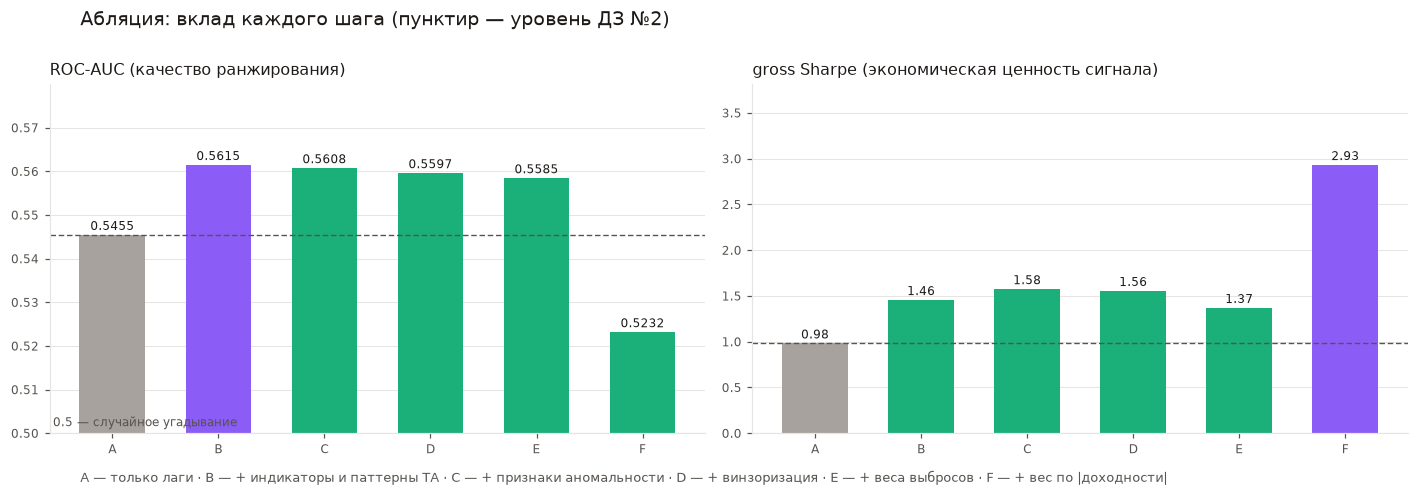

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
labels = [i.split(".")[0] for i in ablation.index]
x = np.arange(len(ablation))
for ax, col, title, fmt in (
        (axes[0], "roc_auc", "ROC-AUC (качество ранжирования)", lambda v: f"{v:.4f}"),
        (axes[1], "gross_sharpe", "gross Sharpe (экономическая ценность сигнала)", lambda v: f"{v:.2f}")):
    vals = ablation[col].to_numpy()
    colors = [COLORS["HW2_Baseline"]] + [COLORS["CatBoost"]] * (len(vals) - 1)
    ax.bar(x, vals, color=colors, width=0.62)
    best = int(np.argmax(vals))
    ax.bar(best, vals[best], color=COLORS["Ensemble"], width=0.62)
    for xi, v in enumerate(vals):
        ax.annotate(fmt(v), xy=(xi, v), xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=8, color=INK)
    ax.axhline(vals[0], color=INK_MUTED, linewidth=0.9, linestyle=(0, (4, 2)))
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(title, color=INK, loc="left", fontsize=10.5)
    # у ROC-AUC содержательный ноль — это 0.5 (случайное угадывание), от него и строим шкалу,
    # иначе разница 0.5455 против 0.5615 визуально неразличима
    floor = 0.5 if col == "roc_auc" else 0.0
    ax.set_ylim(floor, max(vals) + (max(vals) - floor) * 0.30)
    if floor:
        ax.annotate("0.5 — случайное угадывание", xy=(0.005, 0.02), xycoords="axes fraction",
                    fontsize=8, color=INK_MUTED)
    style_ax(ax)
fig.suptitle("Абляция: вклад каждого шага (пунктир — уровень ДЗ №2)",
             fontsize=12.5, color=INK, x=0.06, ha="left", y=1.0)
fig.text(0.06, -0.02, "A — только лаги · B — + индикаторы и паттерны ТА · C — + признаки аномальности · "
                      "D — + винзоризация · E — + веса выбросов · F — + вес по |доходности|",
         fontsize=8.5, color=INK_MUTED)
fig.tight_layout()
plt.show()

### 12.1 Вклад отдельных групп признаков

Обратная абляция: из полного набора по очереди удаляется одна группа. Чем сильнее падает
метрика, тем важнее группа. Важная оговорка: признаки сильно скоррелированы между группами
(RSI, стохастик и Williams %R измеряют почти одно и то же), поэтому удаление одной группы
редко что-то ломает — оставшиеся её «подменяют». Поэтому здесь надо смотреть не на абсолютную
величину, а на знак и на то, какая группа единственная даёт заметное падение.

  без «доходности»: готово


  без «скользящие средние»: готово


  без «осцилляторы»: готово


  без «волатильность»: готово


  без «объём»: готово


...

  без «паттерны продолжения»: готово


  без «аномалии»: готово


  без «календарь»: готово



Полный набор: ROC-AUC = 0.5585, gross Sharpe = 1.372


,признаков осталось,roc_auc,Δ ROC-AUC,gross_sharpe,Δ gross Sharpe
убрана группа,,,,,
свечные паттерны,203,0.5582,-0.0003,1.2241,-0.1480
паттерны разворота,212,0.5588,0.0004,1.4125,0.0404
скользящие средние,199,0.5591,0.0006,1.4320,0.0598
аномалии,238,0.5601,0.0016,1.4958,0.1237
объём,235,0.5601,0.0016,1.5413,0.1692
волатильность,231,0.5613,0.0028,1.5660,0.1939
паттерны продолжения,229,0.5616,0.0031,1.7406,0.3685
доходности,212,0.5580,-0.0005,1.8002,0.4281
календарь,241,0.5583,-0.0002,1.8305,0.4584


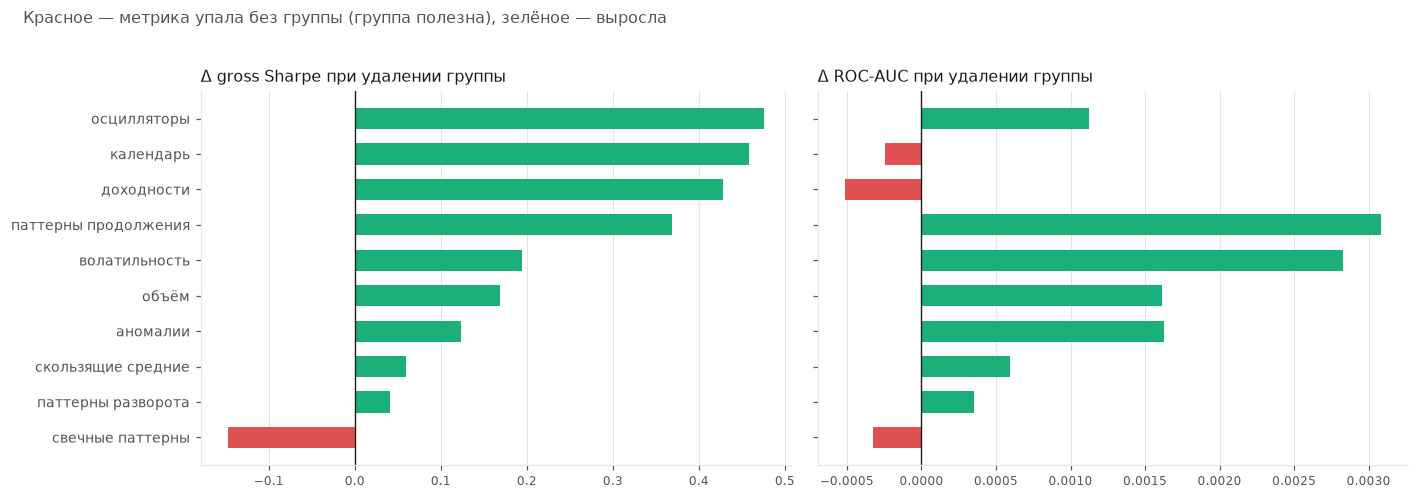

In [22]:
group_rows = []
for gname, gcols in FEATURE_GROUPS.items():
    keep = [c for c in feature_cols if c not in gcols]
    oof, mask = cv_oof(lambda: make_catboost(**CB_FIXED), keep, winsor=True, w_outlier=True)
    group_rows.append({"убрана группа": gname, "признаков осталось": len(keep),
                       **oof_report(oof, mask)})
    print(f"  без «{gname}»: готово")

oof_full, mask_full = cv_oof(lambda: make_catboost(**CB_FIXED), feature_cols,
                             winsor=True, w_outlier=True)
full_report = oof_report(oof_full, mask_full)
group_ablation = pd.DataFrame(group_rows).set_index("убрана группа")
group_ablation["Δ ROC-AUC"] = group_ablation["roc_auc"] - full_report["roc_auc"]
group_ablation["Δ gross Sharpe"] = group_ablation["gross_sharpe"] - full_report["gross_sharpe"]
group_ablation = group_ablation.sort_values("Δ gross Sharpe")
print(f"\nПолный набор: ROC-AUC = {full_report['roc_auc']:.4f}, "
      f"gross Sharpe = {full_report['gross_sharpe']:.3f}")
display(group_ablation[["признаков осталось", "roc_auc", "Δ ROC-AUC",
                        "gross_sharpe", "Δ gross Sharpe"]].round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
yv = np.arange(len(group_ablation))
for ax, col, title in ((axes[0], "Δ gross Sharpe", "Δ gross Sharpe при удалении группы"),
                       (axes[1], "Δ ROC-AUC", "Δ ROC-AUC при удалении группы")):
    ax.barh(yv, group_ablation[col], height=0.6,
            color=[DOWN if v < 0 else UP for v in group_ablation[col]])
    ax.axvline(0, color=INK, linewidth=0.9)
    ax.set_title(title, color=INK, loc="left", fontsize=10.5)
    style_ax(ax, ygrid=False, xgrid=True)
axes[0].set_yticks(yv)
axes[0].set_yticklabels(group_ablation.index, fontsize=9)
fig.suptitle("Красное — метрика упала без группы (группа полезна), зелёное — выросла",
             fontsize=10.5, color=INK_MUTED, x=0.02, ha="left", y=1.02)
fig.tight_layout()
plt.show()

## 13. Выбор горизонта прогноза

Направление следующего часа — самая шумная из возможных целей. Логично проверить, не станет ли
задача легче, если предсказывать направление через 6, 12 или 24 часа: сигнал будет более
инерционным, а значит и позиция будет реже меняться. Сравнение идёт на той же
кросс-валидации, с тем же CatBoost и с разрывом фолдов, равным горизонту.

In [23]:
horizon_rows = []
for H in (1, 6, 12, 24):
    d = feat.copy()
    d["target"] = (d["close"].shift(-H) > d["close"]).astype("float")
    d = d.dropna(subset=["target", "fwd_ret"]).reset_index(drop=True)
    d["target"] = d["target"].astype(int)
    dev_h = d.iloc[:int(len(d) * TEST_END) - H].reset_index(drop=True)
    oof_h, mask_h = cv_oof(lambda: make_catboost(**CB_FIXED), feature_cols,
                           winsor=True, w_outlier=True, data=dev_h,
                           splitter=TimeSeriesSplit(n_splits=N_CV_SPLITS, gap=H))
    rep = oof_report(oof_h, mask_h, data=dev_h)
    # инерционность прогноза: как часто знак сигнала меняется от бара к бару
    sign_flips = float((np.diff((oof_h[mask_h] >= 0.5).astype(int)) != 0).mean())
    horizon_rows.append({"горизонт, ч": H, "roc_auc": rep["roc_auc"], "pr_auc": rep["pr_auc"],
                         "accuracy": rep["accuracy"], "gross_sharpe": rep["gross_sharpe"],
                         "смена знака прогноза, доля баров": sign_flips})
    print(f"  горизонт {H:2d} ч: готово")

horizon_tab = pd.DataFrame(horizon_rows).set_index("горизонт, ч")
display(horizon_tab.round(4))
best_h = int(horizon_tab["roc_auc"].idxmax())
print(f"Лучший горизонт по ROC-AUC: {best_h} ч. "
      f"Дальше используется HORIZON = {HORIZON} ч.")
print("Удлинение горизонта не помогает: ранжирование ухудшается быстрее, чем растёт инерционность\n"
      "прогноза. Проблему оборота решает не горизонт цели, а торговый слой (раздел 14).")

  горизонт  1 ч: готово


  горизонт  6 ч: готово


  горизонт 12 ч: готово


  горизонт 24 ч: готово


,roc_auc,pr_auc,accuracy,gross_sharpe,"смена знака прогноза, доля баров"
"горизонт, ч",,,,,
1,0.5585,0.5504,0.5432,1.3721,0.3308
6,0.5358,0.5322,0.5256,0.7494,0.2128
12,0.5261,0.5235,0.5193,1.0979,0.1435
24,0.5198,0.5244,0.5106,0.7370,0.1112


Лучший горизонт по ROC-AUC: 1 ч. Дальше используется HORIZON = 1 ч.
Удлинение горизонта не помогает: ранжирование ухудшается быстрее, чем растёт инерционность
прогноза. Проблему оборота решает не горизонт цели, а торговый слой (раздел 14).


## 14. Настройка торгового слоя

Берём OOF-вероятности лучшей конфигурации из абляции и перебираем параметры торгового слоя:
режим, ширину зоны неопределённости `q`, окно сглаживания `span` и период ребалансировки.
Все варианты оцениваются по чистому (net) Sharpe на dev-наборе; валидация не участвует.

Правило ДЗ №2 «всегда в рынке»: net Sharpe =  -9.54, оборот =    22463 ед., net = -100.0%
Лучший торговый слой:          net Sharpe =   0.20, оборот =      363 ед., net = +7.3%
  параметры: {'mode': 'long_flat', 'span': 24, 'rebalance': 24, 'q': 0.2}
  оборот снижен в 62 раз

Топ-10 конфигураций по net Sharpe (колонка «прибыльных блоков» — сколько из 5 подпериодов прибыльны; фильтр требует не меньше 3):


,mode,span,rebalance,sharpe,net,gross,turnover,n_trades,time_in_market,экспозиция,sharpe_min_блок,прибыльных блоков,q,scale,допустима
283,long_flat,24,24,0.202,0.073,0.542,363.000,363,0.191,0.191,-1.065,4,0.20,NaN,True
52,hold,1,24,0.131,-0.234,2.098,1397.000,699,0.999,0.999,-1.536,2,0.20,NaN,True
125,hold,4,24,0.092,-0.293,2.045,1459.000,730,0.999,0.999,-1.503,2,0.35,NaN,True
201,flat,12,24,0.080,-0.115,1.049,840.000,750,0.386,0.386,-1.211,1,0.20,NaN,True
120,always,4,24,0.027,-0.381,1.581,1427.000,714,1.000,1.000,-1.483,2,NaN,NaN,True
59,ramp,1,24,0.006,-0.010,0.025,34.718,94,0.034,0.013,-1.258,2,0.02,NaN,False
211,long_flat,12,24,-0.021,-0.135,0.278,390.000,390,0.180,0.180,-1.442,3,0.20,NaN,True
35,ramp,1,6,-0.107,-0.042,0.098,136.546,396,0.036,0.013,-2.514,2,0.02,NaN,False
232,long_flat,24,1,-0.109,-0.094,0.105,198.000,198,0.020,0.020,-2.200,2,0.02,NaN,False
50,hold,1,24,-0.121,-0.542,0.312,1051.000,526,0.999,0.999,-1.442,2,0.05,NaN,True


Из 288 конфигураций 189 удовлетворяют требованиям к активности (оборот от 6 единиц капитала в год и средняя экспозиция от 10%), из них 3 прибыльны хотя бы в 3 подпериодах.


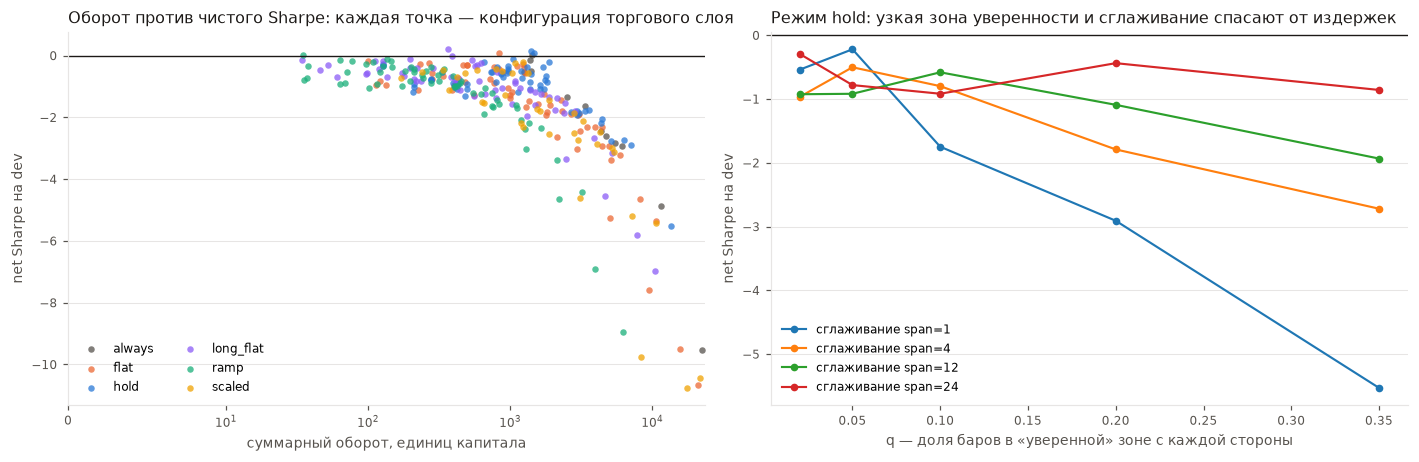

In [24]:
signal_params, signal_tab, signal_ok = tune_signal_layer(
    oof_full[mask_full], dates_dev.to_numpy()[mask_full], fwd_dev.to_numpy()[mask_full])

hw2_rule = signal_tab.query("mode == 'always' and span == 1 and rebalance == 1").iloc[0]
best_row = signal_tab.loc[signal_tab["sharpe"].idxmax()]
print(f"Правило ДЗ №2 «всегда в рынке»: net Sharpe = {hw2_rule['sharpe']:6.2f}, "
      f"оборот = {hw2_rule['turnover']:8.0f} ед., net = {hw2_rule['net']:+.1%}")
print(f"Лучший торговый слой:          net Sharpe = {best_row['sharpe']:6.2f}, "
      f"оборот = {best_row['turnover']:8.0f} ед., net = {best_row['net']:+.1%}")
print(f"  параметры: {signal_params}")
print(f"  оборот снижен в {hw2_rule['turnover'] / max(best_row['turnover'], 1e-9):.0f} раз")
print(f"\nТоп-10 конфигураций по net Sharpe (колонка «прибыльных блоков» — сколько из "
      f"{N_BLOCKS} подпериодов прибыльны; фильтр требует не меньше {MIN_POSITIVE_BLOCKS}):")
display(signal_tab.sort_values("sharpe", ascending=False).head(10).round(3))
n_feasible = int(signal_tab["допустима"].sum())
n_stable = int((signal_tab["допустима"] &
                (signal_tab["прибыльных блоков"] >= MIN_POSITIVE_BLOCKS)).sum())
print(f"Из {len(signal_tab)} конфигураций {n_feasible} удовлетворяют требованиям к активности "
      f"(оборот от {MIN_TURNOVER_PER_YEAR} единиц капитала в год и средняя экспозиция от "
      f"{MIN_AVG_EXPOSURE:.0%}), из них {n_stable} прибыльны хотя бы в "
      f"{MIN_POSITIVE_BLOCKS} подпериодах.")
best_unconstrained = signal_tab.loc[signal_tab["sharpe"].idxmax()]
if not best_unconstrained["допустима"]:
    print(f"Без ограничений победила бы вырожденная конфигурация "
          f"({best_unconstrained['mode']}, Sharpe {best_unconstrained['sharpe']:.2f}) "
          f"с оборотом {best_unconstrained['turnover']:.1f} ед. и средней экспозицией "
          f"{best_unconstrained['экспозиция']:.1%} — она «зарабатывает» тем, что не торгует.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
mode_colors = {"always": INK_MUTED, "hold": COLORS["LogisticRegression"],
               "flat": COLORS["DecisionTree"], "ramp": COLORS["CatBoost"],
               "long_flat": COLORS["Ensemble"], "scaled": "#f0a202"}
for mode, grp in signal_tab.groupby("mode"):
    axes[0].scatter(grp["turnover"], grp["sharpe"], s=18, alpha=0.75,
                    color=mode_colors[mode], label=mode, linewidth=0)
axes[0].axhline(0, color=INK, linewidth=0.9)
axes[0].set_xscale("symlog", linthresh=10)
axes[0].set_xlim(left=0)
axes[0].set_xlabel("суммарный оборот, единиц капитала", color=INK_MUTED, fontsize=9)
axes[0].set_ylabel("net Sharpe на dev", color=INK_MUTED, fontsize=9)
axes[0].set_title("Оборот против чистого Sharpe: каждая точка — конфигурация торгового слоя",
                  color=INK, loc="left", fontsize=10.5)
axes[0].legend(frameon=False, fontsize=8, ncol=2)
style_ax(axes[0])

sub = signal_tab[(signal_tab["mode"] == "hold") & (signal_tab["rebalance"] == 1)]
for span, grp in sub.groupby("span"):
    g = grp.sort_values("q")
    axes[1].plot(g["q"], g["sharpe"], marker="o", markersize=4, linewidth=1.4,
                 label=f"сглаживание span={span}")
axes[1].axhline(0, color=INK, linewidth=0.9)
axes[1].set_xlabel("q — доля баров в «уверенной» зоне с каждой стороны", color=INK_MUTED, fontsize=9)
axes[1].set_ylabel("net Sharpe на dev", color=INK_MUTED, fontsize=9)
axes[1].set_title("Режим hold: узкая зона уверенности и сглаживание спасают от издержек",
                  color=INK, loc="left", fontsize=10.5)
axes[1].legend(frameon=False, fontsize=8)
style_ax(axes[1])
fig.tight_layout()
plt.show()

## 15. Подбор гиперпараметров: Optuna + кросс-валидация временных рядов

> Кросс-валидация временных рядов: данные разбиваются на k частей (fold), обучение идёт на
> частях, предшествующих тестированию, и процедура повторяется k раз.

Используется `TimeSeriesSplit` (расширяющееся окно) на dev-наборе (train + test) с разрывом
`gap = EMBARGO`. Валидационная выборка в подборе не участвует.

Optuna максимизирует **чистый (net) коэффициент Шарпа** — метрику, которая уже включает издержки.
Внутри каждой попытки:

1. считаются OOF-вероятности на 5 фолдах;
2. на них подбирается торговый слой (раздел 14);
3. значением попытки становится net Sharpe при лучшем торговом слое.

Дополнительно перебирается способ взвешивания наблюдений (`w_ret`) — тот самый приём из
раздела 12, который улучшает экономику ценой ROC-AUC. Все остальные метрики сохраняются
в `user_attrs`, чтобы затем сопоставить статистическое качество с экономикой.

**Защита от вырождения.** У задачи «максимизировать Sharpe» есть тривиальное решение:
не торговать. Стратегия с нулевым оборотом не платит комиссий, а если её крошечная
постоянная позиция случайно совпала с направлением рынка на dev-периоде, формальный Sharpe
получается прекрасным. При первом запуске Optuna нашла ровно такой угол: логистическая
регрессия с `C = 3e-4` и штрафом L1 почти обнуляла коэффициенты, выдавала почти постоянную
вероятность, а торговый слой превращал её в неподвижную позицию размером 7% капитала —
CV Sharpe 1.42 при обороте 0.15 единицы в год. Формально это лучший Sharpe из всех, фактически
это buy & hold с плечом 0.07, замаскированный под модель. Поэтому попытка штрафуется значением
`DEGENERATE_PENALTY`, если разброс OOF-вероятностей меньше 0.001 (модель ничего не ранжирует)
или если ни одна конфигурация торгового слоя не проходит требования к активности из раздела 14.

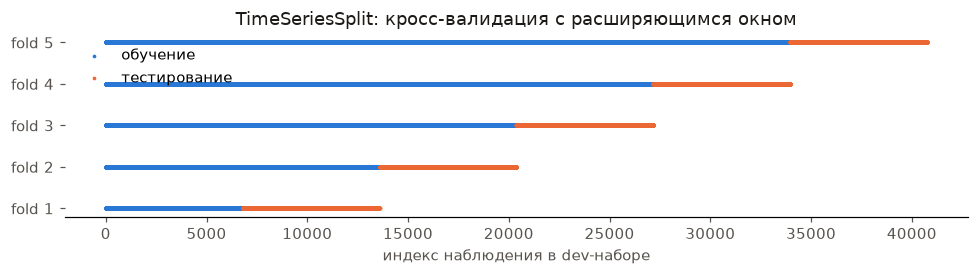

In [25]:
fig, ax = plt.subplots(figsize=(9, 2.6))
for i, (tr_idx, te_idx) in enumerate(tscv.split(X_dev_all)):
    ax.scatter(tr_idx, [i] * len(tr_idx), c=COLORS["LogisticRegression"], s=2,
               label="обучение" if i == 0 else None)
    ax.scatter(te_idx, [i] * len(te_idx), c=COLORS["DecisionTree"], s=2,
               label="тестирование" if i == 0 else None)
ax.set_yticks(range(N_CV_SPLITS))
ax.set_yticklabels([f"fold {i + 1}" for i in range(N_CV_SPLITS)])
ax.set_xlabel("индекс наблюдения в dev-наборе", color=INK_MUTED)
ax.set_title("TimeSeriesSplit: кросс-валидация с расширяющимся окном", color=INK)
ax.legend(loc="upper left", frameon=False)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.tick_params(colors=INK_MUTED)
fig.tight_layout()
plt.show()


DEGENERATE_PENALTY = -10.0        # значение попытки, если модель или слой вырождены


def objective_factory(build_from_params, param_space):
    """Единая целевая функция: OOF -> торговый слой -> net Sharpe."""
    def objective(trial):
        params = param_space(trial)
        w_ret = trial.suggest_categorical("w_ret", [False, True])
        oof, mask = cv_oof(lambda: build_from_params(params), feature_cols,
                           winsor=True, w_outlier=True, w_ret=w_ret)
        d, f = dates_dev.to_numpy()[mask], fwd_dev.to_numpy()[mask]
        # вырожденная модель (почти постоянная вероятность) не ранжирует ничего:
        # любая «прибыль» от неё — это отказ от торговли, а не прогноз
        if float(np.std(oof[mask])) < 1e-3:
            trial.set_user_attr("degenerate", True)
            return DEGENERATE_PENALTY
        sig_prm, _, ok = tune_signal_layer(oof[mask], d, f)
        if not ok:
            trial.set_user_attr("degenerate", True)
            return DEGENERATE_PENALTY
        pos = positions_from_proba(oof[mask], **sig_prm)
        _, trade = backtest(d, f, pos)
        rep = oof_report(oof, mask)
        for k, v in {**rep, **{f"trade_{k}": v for k, v in trade.items()}}.items():
            trial.set_user_attr(k, float(v))
        trial.set_user_attr("signal_params", sig_prm)
        return trade["sharpe"]
    return objective


def run_study(objective, name):
    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    a = study.best_trial.user_attrs
    n_deg = sum(1 for t in study.trials if t.user_attrs.get("degenerate"))
    print(f"{name}: лучший CV net Sharpe = {study.best_value:.3f} "
          f"({N_TRIALS} попыток, отклонено как вырожденные: {n_deg})")
    print(f"  гиперпараметры:  {study.best_params}")
    print(f"  торговый слой:   {a['signal_params']}")
    print(f"  на тех же фолдах: ROC-AUC={a['roc_auc']:.4f}, accuracy={a['accuracy']:.4f}, "
          f"F1={a['f1']:.4f} | net={a['trade_total_return']:+.2%}, "
          f"gross={a['trade_gross_return']:+.2%}, оборот={a['trade_turnover_units']:.0f}")
    return study


def make_logreg(**params):
    # RobustScaler вместо StandardScaler: медиана и межквартильный размах не «съезжают»
    # от экстремальных баров, что важно на тяжёлых хвостах криптодоходностей.
    return Pipeline([
        ("scaler", RobustScaler(quantile_range=(5, 95))),
        ("clf", LogisticRegression(max_iter=500, tol=1e-3, random_state=RANDOM_STATE, **params)),
    ])


def make_tree(**params):
    return DecisionTreeClassifier(random_state=RANDOM_STATE, **params)

In [26]:
def space_logreg(trial):
    params = {
        "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
        "penalty": trial.suggest_categorical("penalty", ["l1", "l2"]),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
    }
    params["solver"] = "saga" if params["penalty"] == "l1" else "lbfgs"
    return params


study_logreg = run_study(objective_factory(lambda p: make_logreg(**p), space_logreg),
                         "LogisticRegression")

LogisticRegression: лучший CV net Sharpe = 1.310 (25 попыток, отклонено как вырожденные: 3)
  гиперпараметры:  {'C': 0.019383567758007342, 'penalty': 'l2', 'class_weight': None, 'w_ret': True}
  торговый слой:   {'mode': 'hold', 'span': 24, 'rebalance': 24, 'q': 0.02}
  на тех же фолдах: ROC-AUC=0.5090, accuracy=0.5060, F1=0.5075 | net=+741.40%, gross=+801.63%, оборот=69


In [27]:
def space_tree(trial):
    return {
        "max_depth": trial.suggest_int("max_depth", 2, 14),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 200),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 300),
        "max_features": trial.suggest_float("max_features", 0.2, 1.0),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
    }


study_tree = run_study(objective_factory(lambda p: make_tree(**p), space_tree), "DecisionTree")

DecisionTree: лучший CV net Sharpe = 1.380 (25 попыток, отклонено как вырожденные: 0)
  гиперпараметры:  {'max_depth': 3, 'min_samples_split': 66, 'min_samples_leaf': 10, 'max_features': 0.4092533856593543, 'criterion': 'entropy', 'w_ret': True}
  торговый слой:   {'mode': 'hold', 'span': 1, 'rebalance': 6, 'q': 0.05}
  на тех же фолдах: ROC-AUC=0.5079, accuracy=0.5030, F1=0.3781 | net=+871.08%, gross=+1043.03%, оборот=163


In [28]:
def space_catboost(trial):
    return {
        "depth": trial.suggest_int("depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 20.0, log=True),
        "iterations": trial.suggest_int("iterations", 100, 500),
        "rsm": trial.suggest_float("rsm", 0.3, 1.0),
    }


study_catboost = run_study(objective_factory(lambda p: make_catboost(**p), space_catboost),
                           "CatBoost")

CatBoost: лучший CV net Sharpe = 0.783 (25 попыток, отклонено как вырожденные: 0)
  гиперпараметры:  {'depth': 4, 'learning_rate': 0.27051668818999286, 'l2_leaf_reg': 10.196967939171484, 'iterations': 476, 'rsm': 0.9263791452993542, 'w_ret': True}
  торговый слой:   {'mode': 'long_flat', 'span': 1, 'rebalance': 24, 'q': 0.1}
  на тех же фолдах: ROC-AUC=0.5277, accuracy=0.5180, F1=0.5282 | net=+81.33%, gross=+134.24%, оборот=256


In [29]:
studies = {"LogisticRegression": study_logreg, "DecisionTree": study_tree, "CatBoost": study_catboost}
tuning_summary = pd.DataFrame([
    {
        "model": name,
        "CV net Sharpe": st.best_value,
        "CV roc_auc": st.best_trial.user_attrs["roc_auc"],
        "CV pr_auc": st.best_trial.user_attrs["pr_auc"],
        "CV gross Sharpe": st.best_trial.user_attrs["gross_sharpe"],
        "CV net": st.best_trial.user_attrs["trade_total_return"],
        "CV оборот": st.best_trial.user_attrs["trade_turnover_units"],
        "вес по |ret|": st.best_params.get("w_ret"),
        "торговый слой": st.best_trial.user_attrs["signal_params"],
    }
    for name, st in studies.items()
]).set_index("model")
display(tuning_summary.drop(columns="торговый слой").round(4))
for name, st in studies.items():
    print(f"{name}:\n  модель: {st.best_params}\n  слой:   {st.best_trial.user_attrs['signal_params']}")

,CV net Sharpe,CV roc_auc,CV pr_auc,CV gross Sharpe,CV net,CV оборот,вес по |ret|
model,,,,,,,
LogisticRegression,1.3104,0.5090,0.5095,1.8779,7.4140,69.0,True
DecisionTree,1.3800,0.5079,0.5097,1.1602,8.7108,163.0,True
CatBoost,0.7828,0.5277,0.5276,1.0343,0.8133,256.0,True


LogisticRegression:
  модель: {'C': 0.019383567758007342, 'penalty': 'l2', 'class_weight': None, 'w_ret': True}
  слой:   {'mode': 'hold', 'span': 24, 'rebalance': 24, 'q': 0.02}
DecisionTree:
  модель: {'max_depth': 3, 'min_samples_split': 66, 'min_samples_leaf': 10, 'max_features': 0.4092533856593543, 'criterion': 'entropy', 'w_ret': True}
  слой:   {'mode': 'hold', 'span': 1, 'rebalance': 6, 'q': 0.05}
CatBoost:
  модель: {'depth': 4, 'learning_rate': 0.27051668818999286, 'l2_leaf_reg': 10.196967939171484, 'iterations': 476, 'rsm': 0.9263791452993542, 'w_ret': True}
  слой:   {'mode': 'long_flat', 'span': 1, 'rebalance': 24, 'q': 0.1}


## 16. Финальные модели

Модели с лучшими гиперпараметрами переобучаются на всём dev-наборе (train + test) — тех же
данных, на которых шёл подбор. Границы винзоризации и веса наблюдений считаются по dev.
Пороги торгового слоя фиксируются по **dev-распределению OOF-вероятностей**: на валидации
используются те же числовые пороги, а не пересчитанные по будущим данным квантили.

Дополнительно строится **ансамбль** — среднее вероятностей трёх моделей. Усреднение снижает
дисперсию прогноза, а значит и число ложных переворотов позиции.

In [30]:
final_specs = {
    "LogisticRegression": (make_logreg, {**{k: v for k, v in study_logreg.best_params.items()
                                            if k != "w_ret"}}),
    "DecisionTree": (make_tree, {k: v for k, v in study_tree.best_params.items() if k != "w_ret"}),
    "CatBoost": (make_catboost, {k: v for k, v in study_catboost.best_params.items() if k != "w_ret"}),
}
final_specs["LogisticRegression"][1]["solver"] = (
    "saga" if final_specs["LogisticRegression"][1]["penalty"] == "l1" else "lbfgs")

dev_bounds = winsor_bounds(dev_df[feature_cols])
X_dev_w = apply_winsor(dev_df[feature_cols], dev_bounds)
X_val_w = apply_winsor(val_df[feature_cols], dev_bounds)
y_dev_full, y_val = dev_df["target"], val_df["target"]

final_models, dev_oof, val_proba, signal_by_model, dev_proba_final = {}, {}, {}, {}, {}
for name, (builder, params) in final_specs.items():
    w_ret = studies[name].best_params.get("w_ret", False)
    # OOF на dev — источник и порогов торгового слоя, и эталонного распределения вероятностей
    oof, mask = cv_oof(lambda: builder(**params), feature_cols,
                       winsor=True, w_outlier=True, w_ret=w_ret)
    dev_oof[name] = (oof, mask)
    signal_by_model[name] = studies[name].best_trial.user_attrs["signal_params"]

    model = builder(**params)
    w = sample_weights(dev_df, np.arange(len(dev_df)), w_outlier=True, w_ret=w_ret)
    if hasattr(model, "steps"):
        model.fit(X_dev_w, y_dev_full, **{f"{model.steps[-1][0]}__sample_weight": w})
    else:
        model.fit(X_dev_w, y_dev_full, sample_weight=w)
    final_models[name] = model
    dev_proba_final[name] = predict_proba1(model, X_dev_w)
    val_proba[name] = predict_proba1(model, X_val_w)
    print(f"{name}: обучена на {len(X_dev_w)} наблюдениях, "
          f"средняя вероятность роста на валидации {val_proba[name].mean():.3f}")

# ансамбль: усреднение вероятностей, торговый слой подбирается на усреднённом OOF
common_mask = np.all([dev_oof[n][1] for n in final_models], axis=0)
ens_oof = np.nanmean(np.vstack([dev_oof[n][0] for n in final_models]), axis=0)
signal_by_model["Ensemble"], _, _ = tune_signal_layer(
    ens_oof[common_mask], dates_dev.to_numpy()[common_mask], fwd_dev.to_numpy()[common_mask])
dev_oof["Ensemble"] = (ens_oof, common_mask)
dev_proba_final["Ensemble"] = np.mean([dev_proba_final[n] for n in final_models], axis=0)
val_proba["Ensemble"] = np.mean([val_proba[n] for n in final_models], axis=0)
print(f"Ensemble: торговый слой {signal_by_model['Ensemble']}")

LogisticRegression: обучена на 40751 наблюдениях, средняя вероятность роста на валидации 0.503


DecisionTree: обучена на 40751 наблюдениях, средняя вероятность роста на валидации 0.504


CatBoost: обучена на 40751 наблюдениях, средняя вероятность роста на валидации 0.508


Ensemble: торговый слой {'mode': 'hold', 'span': 24, 'rebalance': 6, 'q': 0.02}


In [31]:
# Устойчивость выбранных стратегий на dev: Sharpe по подпериодам OOF-периода.
stability_rows = []
for name in list(final_models) + ["Ensemble"]:
    oof, mask = dev_oof[name]
    pos = positions_from_proba(oof[mask], **signal_by_model[name])
    curve, m = backtest(dates_dev.to_numpy()[mask], fwd_dev.to_numpy()[mask], pos)
    blocks = np.array_split(curve["strategy_return"].to_numpy(), N_BLOCKS)
    row = {"стратегия": name, "net Sharpe (весь dev)": m["sharpe"]}
    for bi, b in enumerate(blocks, 1):
        row[f"блок {bi}"] = float(b.mean() / b.std(ddof=0) * np.sqrt(PERIODS_PER_YEAR)) if b.std(ddof=0) > 0 else 0.0
    row["прибыльных блоков"] = int(sum(row[f"блок {bi}"] > 0 for bi in range(1, N_BLOCKS + 1)))
    stability_rows.append(row)
print("Sharpe по подпериодам dev-выборки (проверка, что результат не держится на одной сделке):")
display(pd.DataFrame(stability_rows).set_index("стратегия").round(3))

Sharpe по подпериодам dev-выборки (проверка, что результат не держится на одной сделке):


,net Sharpe (весь dev),блок 1,блок 2,блок 3,блок 4,блок 5,прибыльных блоков
стратегия,,,,,,,
LogisticRegression,1.310,0.569,1.402,3.328,1.358,0.524,5
DecisionTree,1.380,1.664,0.834,2.708,1.318,0.524,5
CatBoost,0.783,0.465,1.987,1.182,2.387,-0.536,4
Ensemble,0.896,1.260,1.239,0.344,0.922,0.524,5


### 16.1 Воспроизведение стратегии ДЗ №2 как точки отсчёта

Чтобы улучшение измерялось честно, рядом строится стратегия из ДЗ №2 на тех же выборках:
CatBoost по одним лагам доходности, без обработки выбросов, правило «всегда в рынке».

In [32]:
hw2_model = make_catboost(iterations=200, depth=4, learning_rate=0.05)
hw2_model.fit(dev_df[lag_cols], y_dev_full)
hw2_val_proba = predict_proba1(hw2_model, val_df[lag_cols])
print(f"ДЗ №2: {len(lag_cols)} признаков-лагов, правило «всегда в рынке», без торгового слоя.")

# «ТА без слоя»: те же признаки и обработка выбросов, что в ДЗ №3, но правило торговли из ДЗ №2.
# Эта промежуточная точка отделяет вклад признаков от вклада торгового слоя на валидации.
ta_model = make_catboost(**CB_FIXED)
ta_model.fit(X_dev_w, y_dev_full,
             sample_weight=sample_weights(dev_df, np.arange(len(dev_df)), w_outlier=True))
ta_val_proba = predict_proba1(ta_model, X_val_w)
print(f"ТА без слоя: {len(feature_cols)} признаков ТА + обработка выбросов, "
      f"правило торговли то же — «всегда в рынке».")

ДЗ №2: 12 признаков-лагов, правило «всегда в рынке», без торгового слоя.


ТА без слоя: 246 признаков ТА + обработка выбросов, правило торговли то же — «всегда в рынке».


## 17. Финальное тестирование на валидационной выборке

In [33]:
def apply_signal(proba, params, ref_proba):
    """Применение торгового слоя с порогами, зафиксированными по dev-распределению.

    Квантильные пороги считаются по прогнозам ФИНАЛЬНОЙ модели на dev, а не по OOF:
    деплоится именно финальная модель, и её распределение вероятностей отличается от
    OOF (особенно у неглубокого дерева, у которого всего несколько возможных значений).
    Взяв пороги из чужого распределения, легко получить стратегию, которая на валидации
    не совершает ни одной сделки.
    """
    span = int(params.get("span", 1))
    ref = (pd.Series(ref_proba).ewm(span=span, adjust=False).mean().to_numpy()
           if span > 1 else np.asarray(ref_proba))
    return positions_from_proba(proba, ref=ref, **params)


val_dates, val_fwd = val_df["date"].to_numpy(), val_df["fwd_ret"].to_numpy()
val_curves, val_rows, val_positions = {}, [], {}

bh_pos = np.ones(len(val_df))
bh_curve, bh_trade = backtest(val_dates, val_fwd, bh_pos)
val_curves["BuyAndHold"] = bh_curve
val_positions["BuyAndHold"] = bh_pos
val_rows.append({"strategy": "BuyAndHold",
                 **classification_metrics(y_val, np.ones(len(val_df), dtype=int),
                                          np.full(len(val_df), 0.5)),
                 **bh_trade})

hw2_pos = np.where(hw2_val_proba >= 0.5, 1.0, -1.0)
hw2_curve, hw2_trade = backtest(val_dates, val_fwd, hw2_pos)
val_curves["HW2_Baseline"] = hw2_curve
val_positions["HW2_Baseline"] = hw2_pos
val_rows.append({"strategy": "HW2_Baseline",
                 **classification_metrics(y_val, (hw2_val_proba >= 0.5).astype(int), hw2_val_proba),
                 **hw2_trade})

ta_pos = np.where(ta_val_proba >= 0.5, 1.0, -1.0)
ta_curve, ta_trade = backtest(val_dates, val_fwd, ta_pos)
val_curves["TA_AlwaysIn"] = ta_curve
val_positions["TA_AlwaysIn"] = ta_pos
val_rows.append({"strategy": "TA_AlwaysIn",
                 **classification_metrics(y_val, (ta_val_proba >= 0.5).astype(int), ta_val_proba),
                 **ta_trade})

for name in list(final_models) + ["Ensemble"]:
    proba = val_proba[name]
    pos = apply_signal(proba, signal_by_model[name], dev_proba_final[name])
    curve, trade = backtest(val_dates, val_fwd, pos)
    val_curves[name] = curve
    val_positions[name] = pos
    val_rows.append({"strategy": name,
                     **classification_metrics(y_val, (proba >= 0.5).astype(int), proba),
                     **trade})

val_comparison = pd.DataFrame(val_rows).set_index("strategy")
strategies = list(val_curves)

print(f"Валидация: {len(val_df)} часовых баров, {val_df['date'].min()} — {val_df['date'].max()}")
print(f"Buy & hold за период: {bh_trade['total_return']:+.1%}\n")
print("Качество классификации:")
display(val_comparison[CLS_COLS].round(4))
print("Экономика стратегии:")
display(val_comparison[TRADE_COLS].round(4))
print("\nКак читать:")
print("  roc_auc ~ 0.5   — модель не отличает рост от падения")
print("  gross_return    — доходность БЕЗ издержек: есть ли у модели предсказательный edge")
print("  fee_drag        — сколько капитала съели комиссии")
print("  total_return    — net: то, что реально осталось бы у трейдера")

print("\nСколько решений на самом деле принято на валидации:")
for nm in strategies:
    tr = int(val_comparison.loc[nm, "n_trades"])
    print(f"  {SHORT[nm]:12s}: {tr:5d} изменений позиции, "
          f"в рынке {val_comparison.loc[nm, 'time_in_market']:.0%} времени")
print("Чем меньше сделок, тем шире доверительный интервал у Sharpe: результат стратегии,")
print("сделавшей единицы сделок за 10 месяцев, определяется удачей в этих единицах сделок,")
print("а не устойчивым преимуществом. Это ограничение подхода, а не его достоинство.")

Валидация: 7192 часовых баров, 2025-09-23 08:00:00 — 2026-07-19 23:00:00
Buy & hold за период: -43.0%

Качество классификации:


,accuracy,precision,recall,f1,roc_auc,pr_auc
strategy,,,,,,
BuyAndHold,0.4967,0.4967,1.0000,0.6637,0.5000,0.4967
HW2_Baseline,0.5316,0.5269,0.5560,0.5411,0.5418,0.5265
TA_AlwaysIn,0.5310,0.5260,0.5627,0.5438,0.5456,0.5396
LogisticRegression,0.5096,0.5059,0.5358,0.5205,0.5146,0.5098
DecisionTree,0.5114,0.5108,0.3847,0.4388,0.5122,0.5064
CatBoost,0.5147,0.5109,0.5386,0.5244,0.5163,0.5048
Ensemble,0.5182,0.5142,0.5417,0.5276,0.5213,0.5097


Экономика стратегии:


,gross_return,fee_drag,total_return,sharpe,max_drawdown,n_trades,turnover_units,avg_abs_position
strategy,,,,,,,,
BuyAndHold,-0.4293,0.001,-0.4299,-1.2780,-0.5376,1,1.0,1.0000
HW2_Baseline,0.2776,4.865,-0.9902,-11.9252,-0.9903,2433,4865.0,1.0000
TA_AlwaysIn,0.1585,4.673,-0.9892,-11.6884,-0.9893,2337,4673.0,1.0000
LogisticRegression,0.3383,0.029,0.3001,0.9305,-0.2429,15,29.0,1.0000
DecisionTree,0.3623,0.501,-0.1750,-0.2860,-0.3780,251,501.0,1.0000
CatBoost,-0.0134,0.038,-0.0502,-0.3834,-0.1763,38,38.0,0.0634
Ensemble,-0.4691,0.037,-0.4884,-1.5672,-0.5417,19,37.0,1.0000



Как читать:
  roc_auc ~ 0.5   — модель не отличает рост от падения
  gross_return    — доходность БЕЗ издержек: есть ли у модели предсказательный edge
  fee_drag        — сколько капитала съели комиссии
  total_return    — net: то, что реально осталось бы у трейдера

Сколько решений на самом деле принято на валидации:
  B&H         :     1 изменений позиции, в рынке 100% времени
  ДЗ№2        :  2433 изменений позиции, в рынке 100% времени
  ТА без слоя :  2337 изменений позиции, в рынке 100% времени
  LogReg      :    15 изменений позиции, в рынке 100% времени
  Tree        :   251 изменений позиции, в рынке 100% времени
  CatBoost    :    38 изменений позиции, в рынке 6% времени
  Ансамбль    :    19 изменений позиции, в рынке 100% времени
Чем меньше сделок, тем шире доверительный интервал у Sharpe: результат стратегии,
сделавшей единицы сделок за 10 месяцев, определяется удачей в этих единицах сделок,
а не устойчивым преимуществом. Это ограничение подхода, а не его достоинство.


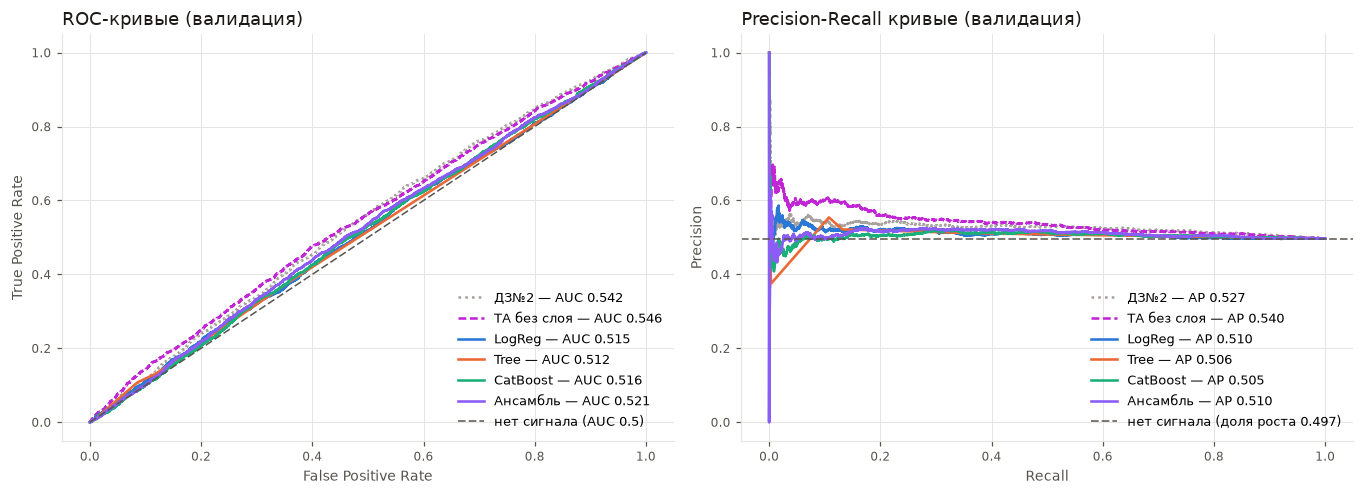

In [34]:
prevalence = float(y_val.mean())
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12.5, 4.6))
curve_models = ["HW2_Baseline", "TA_AlwaysIn"] + list(final_models) + ["Ensemble"]
proba_map = {"HW2_Baseline": hw2_val_proba, "TA_AlwaysIn": ta_val_proba, **val_proba}
for name in curve_models:
    prob = proba_map[name]
    fpr, tpr, _ = roc_curve(y_val, prob)
    ax_roc.plot(fpr, tpr, color=COLORS[name], linewidth=1.7,
                linestyle=STYLES.get(name, "-"),
                label=f"{SHORT[name]} — AUC {val_comparison.loc[name, 'roc_auc']:.3f}")
    prec, rec, _ = precision_recall_curve(y_val, prob)
    ax_pr.plot(rec, prec, color=COLORS[name], linewidth=1.7, linestyle=STYLES.get(name, "-"),
               label=f"{SHORT[name]} — AP {val_comparison.loc[name, 'pr_auc']:.3f}")
ax_roc.plot([0, 1], [0, 1], color=INK_MUTED, linewidth=1.0, linestyle=(0, (5, 2)),
            label="нет сигнала (AUC 0.5)")
ax_roc.set_xlabel("False Positive Rate", color=INK_MUTED, fontsize=9)
ax_roc.set_ylabel("True Positive Rate", color=INK_MUTED, fontsize=9)
ax_roc.set_title("ROC-кривые (валидация)", color=INK, fontsize=11.5, loc="left")
ax_pr.axhline(prevalence, color=INK_MUTED, linewidth=1.0, linestyle=(0, (5, 2)),
              label=f"нет сигнала (доля роста {prevalence:.3f})")
ax_pr.set_xlabel("Recall", color=INK_MUTED, fontsize=9)
ax_pr.set_ylabel("Precision", color=INK_MUTED, fontsize=9)
ax_pr.set_title("Precision-Recall кривые (валидация)", color=INK, fontsize=11.5, loc="left")
for ax in (ax_roc, ax_pr):
    ax.legend(frameon=False, fontsize=8.5, loc="lower right")
    ax.grid(color=GRID, linewidth=0.7)
    style_ax(ax, ygrid=False)
    ax.grid(color=GRID, linewidth=0.7)
fig.tight_layout()
plt.show()

## 18. Чувствительность к издержкам и точка безубыточности

Итоговый вывод целиком зависит от заложенной комиссии. Если у стратегии положительная
gross-доходность, существует **пороговый уровень издержек (break-even fee)**, ниже которого
она прибыльна. Этот порог информативнее net-доходности при одном произвольном тарифе: он
говорит, на какой инфраструктуре стратегия имела бы смысл.

Для справки: taker-комиссия на BTC-перпетуалах крупных бирж — 0.04–0.055% за сторону,
maker — 0.01–0.02%, то есть ниже заложенных нами 0.1%.

In [35]:
FEE_GRID = np.linspace(0.0, 0.0015, 61)
sensitivity = pd.DataFrame(
    {name: [backtest(val_dates, val_fwd, pos, fee_rate=f)[1]["total_return"] for f in FEE_GRID]
     for name, pos in val_positions.items()}, index=FEE_GRID)

break_even = {}
for name, pos in val_positions.items():
    f = lambda fee: backtest(val_dates, val_fwd, pos, fee_rate=fee)[1]["total_return"]
    if f(0.0) <= 0:
        break_even[name] = np.nan                      # edge нет даже при нулевых издержках
    elif f(FEE_GRID[-1]) > 0:
        break_even[name] = np.inf                      # прибыльна на всей сетке
    else:
        break_even[name] = brentq(f, 0.0, FEE_GRID[-1])

be = pd.DataFrame({
    "gross (fee=0)": [sensitivity[n].iloc[0] for n in val_positions],
    "break_even_fee": [break_even[n] for n in val_positions],
    "net при 0.10%": [val_comparison.loc[n, "total_return"] for n in val_positions],
    "оборот": [val_comparison.loc[n, "turnover_units"] for n in val_positions],
}, index=list(val_positions)).rename_axis("strategy")
display(be.round(6))

scenario = pd.DataFrame({
    label: {name: backtest(val_dates, val_fwd, pos, fee_rate=fee)[1]["total_return"]
            for name, pos in val_positions.items()}
    for label, fee in FEE_SCENARIOS.items()})
print("Net-доходность на валидации при разных тарифах:")
display(scenario.map(lambda vv: f"{vv:+.2%}"))

for nm, vv in break_even.items():
    if np.isnan(vv):
        print(f"{nm:20s}: edge отсутствует даже при нулевых издержках")
    elif np.isinf(vv):
        print(f"{nm:20s}: прибыльна на всём диапазоне сетки")
    else:
        print(f"{nm:20s}: безубыточна при комиссии < {vv * 100:.4f}% за единицу оборота "
              f"({'выше' if vv > FEE_RATE else 'ниже'} заложенных {FEE_RATE * 100:.2f}%)")

,gross (fee=0),break_even_fee,net при 0.10%,оборот
strategy,,,,
BuyAndHold,-0.429319,NaN,-0.429891,1.0
HW2_Baseline,0.277584,0.000050,-0.990194,4865.0
TA_AlwaysIn,0.158489,0.000031,-0.989224,4673.0
LogisticRegression,0.338308,inf,0.300090,29.0
DecisionTree,0.362284,0.000617,-0.174990,501.0
CatBoost,-0.013398,NaN,-0.050210,38.0
Ensemble,-0.469069,NaN,-0.488406,37.0


Net-доходность на валидации при разных тарифах:


,0.10% (ДЗ №2),0.05% (taker),0.02% (maker),0.00% (без издержек)
BuyAndHold,-42.99%,-42.96%,-42.94%,-42.93%
HW2_Baseline,-99.02%,-88.79%,-51.72%,+27.76%
TA_AlwaysIn,-98.92%,-88.81%,-54.51%,+15.85%
LogisticRegression,+30.01%,+31.91%,+33.06%,+33.83%
DecisionTree,-17.50%,+6.03%,+23.24%,+36.23%
CatBoost,-5.02%,-3.20%,-2.09%,-1.34%
Ensemble,-48.84%,-47.88%,-47.30%,-46.91%


BuyAndHold          : edge отсутствует даже при нулевых издержках
HW2_Baseline        : безубыточна при комиссии < 0.0050% за единицу оборота (ниже заложенных 0.10%)
TA_AlwaysIn         : безубыточна при комиссии < 0.0031% за единицу оборота (ниже заложенных 0.10%)
LogisticRegression  : прибыльна на всём диапазоне сетки
DecisionTree        : безубыточна при комиссии < 0.0617% за единицу оборота (ниже заложенных 0.10%)
CatBoost            : edge отсутствует даже при нулевых издержках
Ensemble            : edge отсутствует даже при нулевых издержках


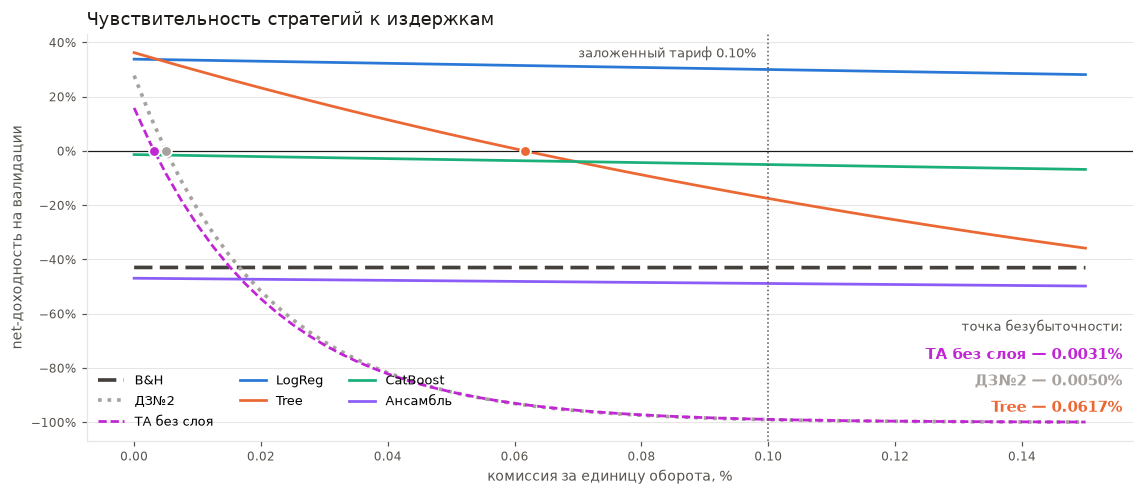

In [36]:
fig, ax = plt.subplots(figsize=(10.5, 4.6))
for name in sensitivity.columns:
    ax.plot(sensitivity.index * 100, sensitivity[name], color=COLORS[name],
            linewidth=2.4 if name in ("BuyAndHold", "HW2_Baseline") else 1.8,
            linestyle=STYLES.get(name, "-"), label=SHORT[name])
ax.axhline(0, color=INK, linewidth=0.8)
ax.axvline(FEE_RATE * 100, color=INK_MUTED, linewidth=1.0, linestyle=":")
ax.annotate(f"заложенный тариф {FEE_RATE * 100:.2f}%", xy=(FEE_RATE * 100, 0.97),
            xycoords=("data", "axes fraction"), xytext=(-8, 0), textcoords="offset points",
            ha="right", va="top", fontsize=8.5, color=INK_MUTED)
finite_be = sorted([(nm, vv) for nm, vv in break_even.items() if np.isfinite(vv) and vv > 0],
                   key=lambda t: t[1])
for nm, vv in finite_be:
    ax.plot([vv * 100], [0], marker="o", markersize=7, color=COLORS[nm],
            markeredgecolor="white", markeredgewidth=1.2, zorder=5)
ax.text(0.99, 0.28, "точка безубыточности:", transform=ax.transAxes, ha="right", va="center",
        fontsize=8.5, color=INK_MUTED)
for k, (nm, vv) in enumerate(finite_be):
    ax.text(0.99, 0.21 - k * 0.065, f"{SHORT[nm]} — {vv * 100:.4f}%", transform=ax.transAxes,
            ha="right", va="center", fontsize=9.5, color=COLORS[nm], fontweight="bold")
ax.set_xlabel("комиссия за единицу оборота, %", color=INK_MUTED, fontsize=9)
ax.set_ylabel("net-доходность на валидации", color=INK_MUTED, fontsize=9)
ax.set_title("Чувствительность стратегий к издержкам", color=INK, fontsize=11.5, loc="left")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.legend(frameon=False, fontsize=8.5, loc="lower left", ncol=3)
style_ax(ax)
fig.tight_layout()
plt.show()

## 19. Важность признаков

CatBoost показывает, на какие признаки он реально опирается. Важности агрегируются и по
отдельным признакам, и по группам — второе устойчивее, потому что близкие индикаторы делят
важность между собой.

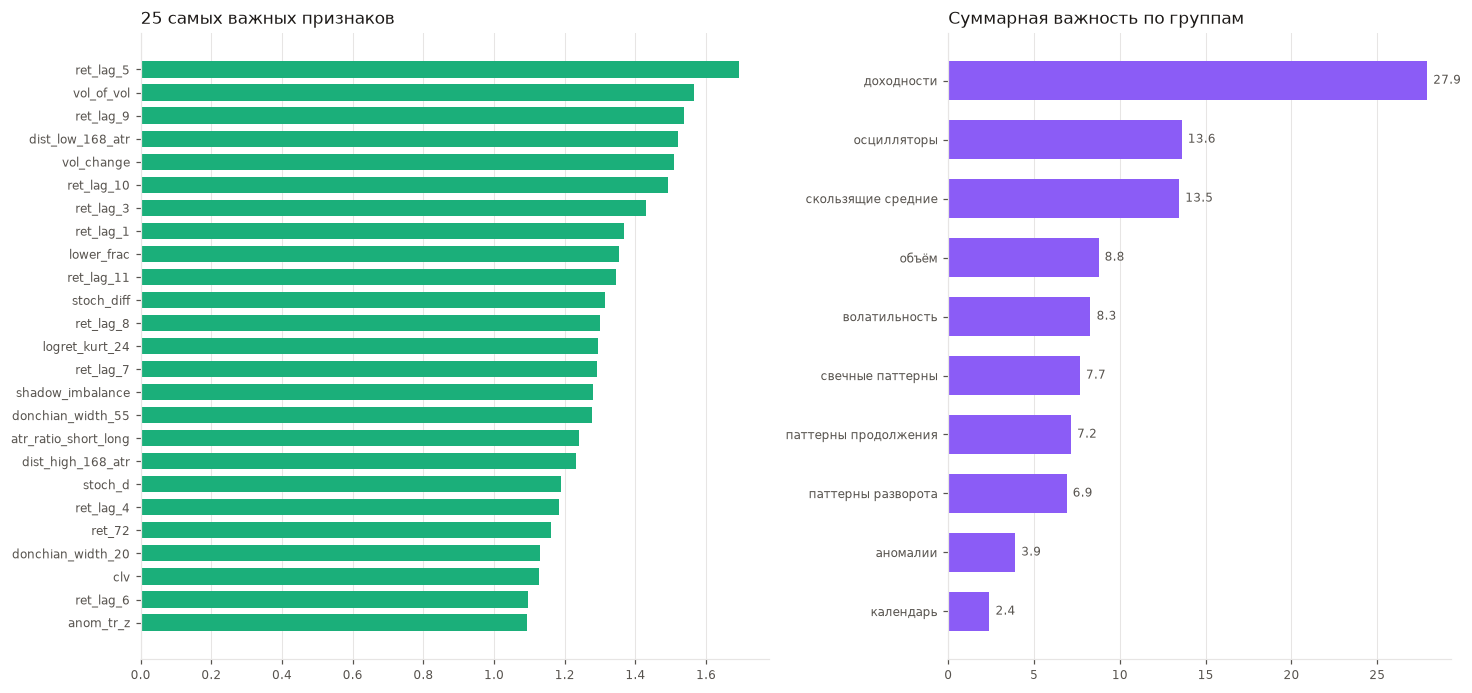

Самые важные паттерны технического анализа:


,паттерн,важность
cdl_net_score_6,перевес бычьих свечей за 6 ч,0.379
cdl_outside_bar_bear,внешний бар медвежий,0.143
cdl_spinning_top,волчок,0.141
pat_bull_divergence_24,бычья дивергенция RSI,0.129
cdl_net_score,перевес бычьих свечей,0.126
pat_bear_divergence_24,медвежья дивергенция RSI,0.115
pat_inv_head_shoulders_24,перевёрнутые голова и плечи,0.106
pat_double_top_24,двойная вершина,0.102
pat_triple_top_24,тройная вершина,0.097
pat_bull_flag,бычий флаг,0.088


In [37]:
imp = pd.Series(final_models["CatBoost"].get_feature_importance(), index=feature_cols)
group_of = {c: g for g, cols in FEATURE_GROUPS.items() for c in cols}
imp_by_group = imp.groupby(imp.index.map(group_of)).sum().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.4), gridspec_kw={"width_ratios": [1.25, 1]})
top_imp = imp.sort_values().tail(25)
axes[0].barh(np.arange(len(top_imp)), top_imp.to_numpy(), color=COLORS["CatBoost"], height=0.7)
axes[0].set_yticks(np.arange(len(top_imp)))
axes[0].set_yticklabels(top_imp.index, fontsize=8)
axes[0].set_title("25 самых важных признаков", color=INK, loc="left", fontsize=11)
style_ax(axes[0], ygrid=False, xgrid=True)

axes[1].barh(np.arange(len(imp_by_group)), imp_by_group.to_numpy(),
             color=COLORS["Ensemble"], height=0.65)
axes[1].set_yticks(np.arange(len(imp_by_group)))
axes[1].set_yticklabels(imp_by_group.index, fontsize=9)
axes[1].set_title("Суммарная важность по группам", color=INK, loc="left", fontsize=11)
for yi, vv in enumerate(imp_by_group.to_numpy()):
    axes[1].annotate(f"{vv:.1f}", xy=(vv, yi), xytext=(4, 0), textcoords="offset points",
                     va="center", fontsize=8, color=INK_MUTED)
style_ax(axes[1], ygrid=False, xgrid=True)
fig.tight_layout()
plt.show()

top_patterns = imp[[c for c in feature_cols if c.startswith(("cdl_", "pat_"))]].sort_values(ascending=False)
print("Самые важные паттерны технического анализа:")
display(pd.DataFrame({
    "паттерн": [CANDLE_RU.get(c, PATTERN_RU.get(c.replace("_24", ""), c)) for c in top_patterns.head(12).index],
    "важность": top_patterns.head(12).round(3).to_numpy(),
}, index=top_patterns.head(12).index))

## 20. Дашборд эффективности стратегий во времени

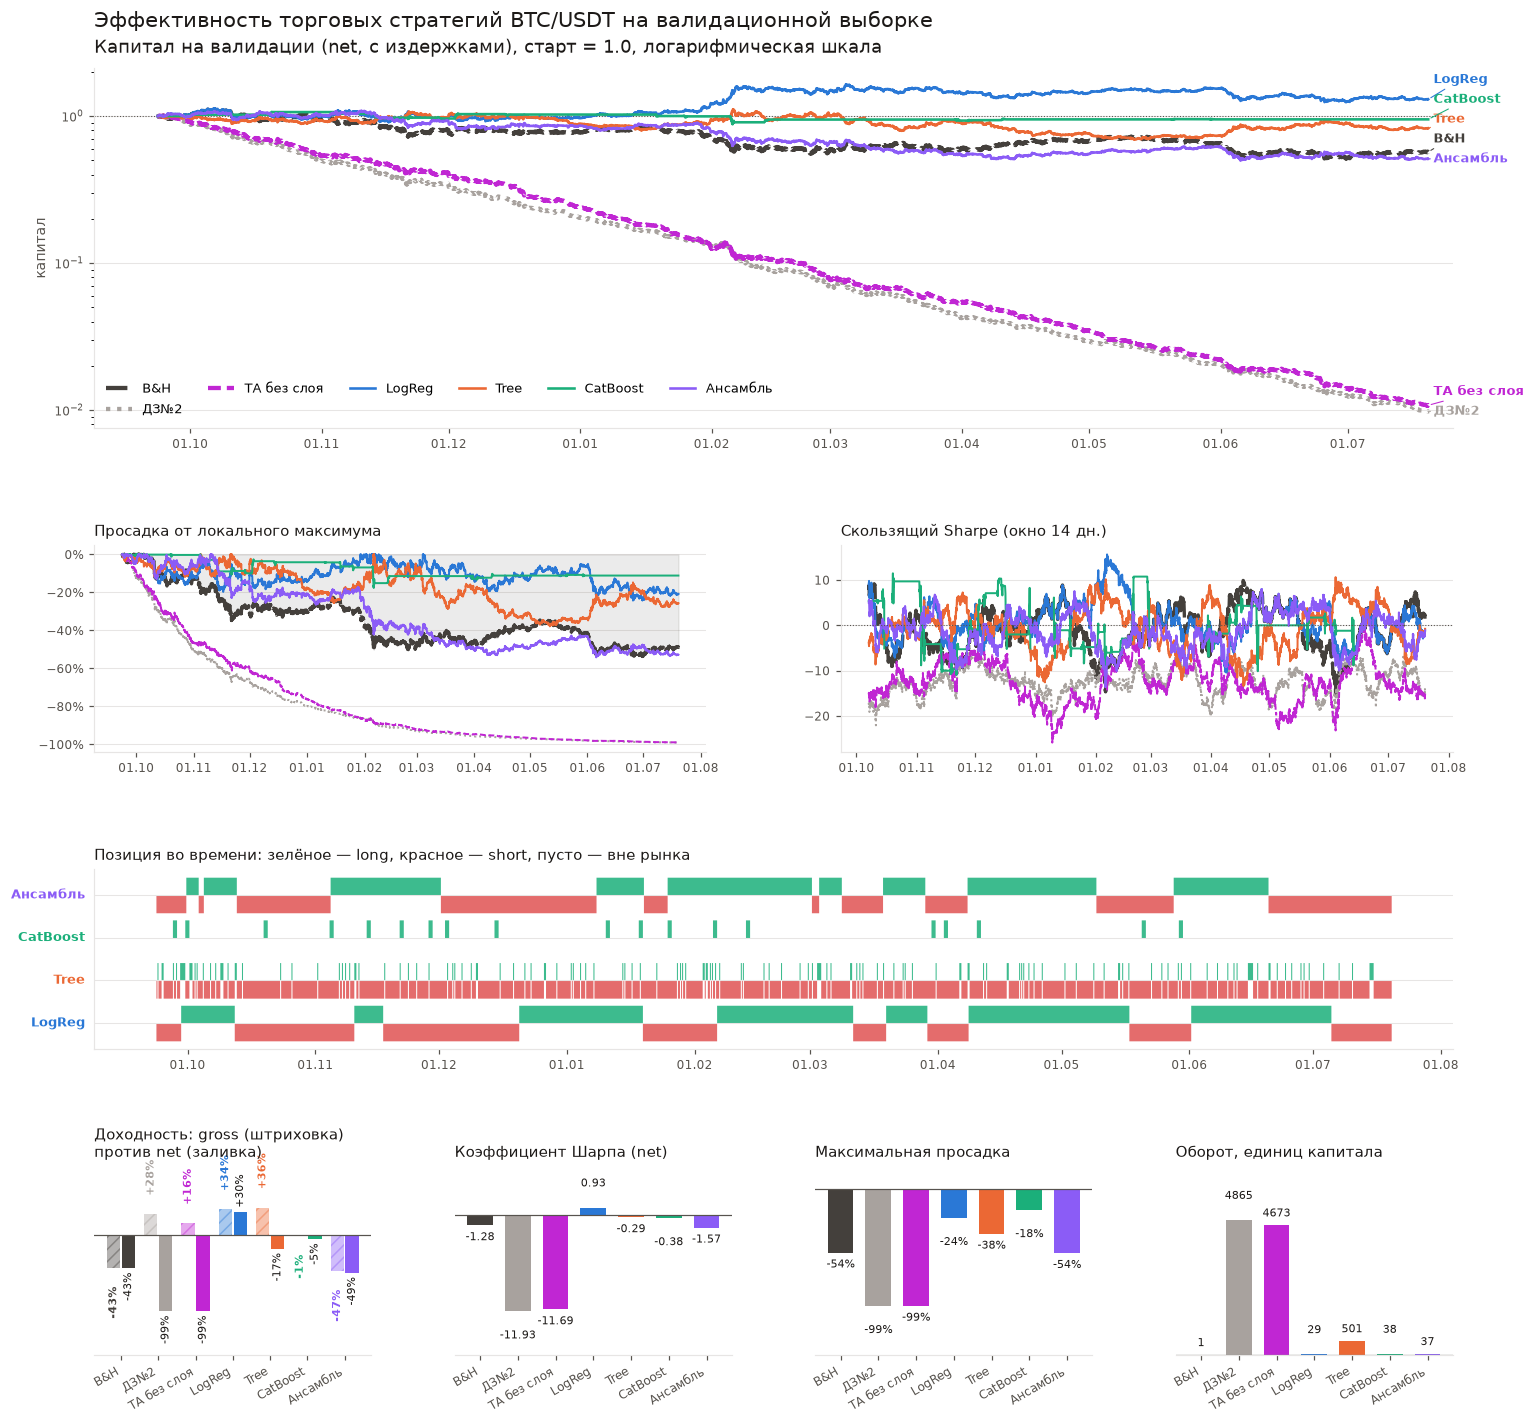

In [38]:
def declutter(pairs, min_gap):
    """Раздвигает подписи по вертикали, чтобы они не накладывались."""
    out, prev = {}, None
    for name, y in sorted(pairs, key=lambda t: t[1]):
        if prev is not None and y - prev < min_gap:
            y = prev + min_gap
        out[name], prev = y, y
    return out


fig = plt.figure(figsize=(13.5, 13))
gs = fig.add_gridspec(4, 2, height_ratios=[2.0, 1.15, 1.0, 1.05], hspace=0.5, wspace=0.22,
                      top=0.945, bottom=0.045, left=0.06, right=0.975)

# ── 1. кривые капитала (net) ────────────────────────────────────────────────
ax_eq = fig.add_subplot(gs[0, :])
for name in strategies:
    curve = val_curves[name]
    bench = name in ("BuyAndHold", "HW2_Baseline", "TA_AlwaysIn")
    ax_eq.plot(curve["date"], curve["equity"], color=COLORS[name],
               linewidth=2.8 if bench else 1.7, linestyle=STYLES.get(name, "-"),
               zorder=2 if bench else 3, label=SHORT[name])
ax_eq.axhline(1.0, color=INK_MUTED, linewidth=0.7, linestyle=":", zorder=1)
ax_eq.set_yscale("log")
last_x = val_curves["BuyAndHold"]["date"].iloc[-1]
ax_eq.set_xlim(right=last_x + pd.Timedelta(hours=140))
lo_y, hi_y = ax_eq.get_ylim()
span_log = np.log10(hi_y) - np.log10(lo_y)
ends = declutter([(nm, float(np.log10(max(val_curves[nm]["equity"].iloc[-1], 1e-6))))
                  for nm in strategies], span_log * 0.055)
for name in strategies:
    y_true = float(val_curves[name]["equity"].iloc[-1])
    ax_eq.annotate(SHORT[name], xy=(last_x, max(y_true, 1e-6)),
                   xytext=(last_x + pd.Timedelta(hours=30), 10 ** ends[name]), textcoords="data",
                   va="center", fontsize=8.5, color=COLORS[name], fontweight="bold",
                   annotation_clip=False,
                   arrowprops=dict(arrowstyle="-", color=COLORS[name], linewidth=0.7,
                                   shrinkA=0, shrinkB=2))
ax_eq.set_title("Капитал на валидации (net, с издержками), старт = 1.0, логарифмическая шкала",
                color=INK, fontsize=11.5, loc="left", pad=10)
ax_eq.set_ylabel("капитал", color=INK_MUTED, fontsize=9)
ax_eq.legend(loc="lower left", frameon=False, fontsize=8.5, ncol=6)
ax_eq.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax_eq)

# ── 2. просадка ─────────────────────────────────────────────────────────────
ax_dd = fig.add_subplot(gs[1, 0])
ax_dd.fill_between(val_curves["BuyAndHold"]["date"], val_curves["BuyAndHold"]["drawdown"], 0,
                   color=COLORS["BuyAndHold"], alpha=0.10, zorder=1)
for name in strategies:
    curve = val_curves[name]
    ax_dd.plot(curve["date"], curve["drawdown"], color=COLORS[name],
               linewidth=2.2 if name == "BuyAndHold" else 1.3,
               linestyle=STYLES.get(name, "-"), zorder=2)
ax_dd.set_title("Просадка от локального максимума", color=INK, fontsize=10, loc="left")
ax_dd.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax_dd.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax_dd)

# ── 3. скользящий Sharpe ────────────────────────────────────────────────────
ax_roll = fig.add_subplot(gs[1, 1])
window = 24 * 14
for name in strategies:
    curve = val_curves[name]
    r = curve["strategy_return"]
    roll = (r.rolling(window).mean() / r.rolling(window).std()) * np.sqrt(PERIODS_PER_YEAR)
    ax_roll.plot(curve["date"], roll, color=COLORS[name],
                 linewidth=2.2 if name == "BuyAndHold" else 1.3, linestyle=STYLES.get(name, "-"))
ax_roll.axhline(0.0, color=INK_MUTED, linewidth=0.7, linestyle=":")
ax_roll.set_title(f"Скользящий Sharpe (окно {window // 24} дн.)", color=INK, fontsize=10, loc="left")
ax_roll.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax_roll)

# ── 4. позиция во времени: видно, как работает торговый слой ────────────────
ax_pos = fig.add_subplot(gs[2, :])
show_pos = [nm for nm in strategies if nm not in ("BuyAndHold", "HW2_Baseline", "TA_AlwaysIn")]
for k, name in enumerate(show_pos):
    pos = val_positions[name]
    ax_pos.fill_between(val_dates, k * 2.4 + np.clip(pos, 0, 1), k * 2.4,
                        color=UP, linewidth=0, alpha=0.85, step="post")
    ax_pos.fill_between(val_dates, k * 2.4 + np.clip(pos, -1, 0), k * 2.4,
                        color=DOWN, linewidth=0, alpha=0.85, step="post")
    ax_pos.axhline(k * 2.4, color=GRID, linewidth=0.7)
    ax_pos.annotate(SHORT[name], xy=(0, k * 2.4), xycoords=("axes fraction", "data"),
                    xytext=(-6, 0), textcoords="offset points", ha="right", va="center",
                    fontsize=8.5, color=COLORS[name], fontweight="bold")
ax_pos.set_yticks([])
ax_pos.set_title("Позиция во времени: зелёное — long, красное — short, пусто — вне рынка",
                 color=INK, fontsize=10, loc="left")
ax_pos.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax_pos, ygrid=False)

# ── 5. сводные метрики: у каждой своя шкала ─────────────────────────────────
inner = gs[3, :].subgridspec(1, 4, wspace=0.3)
x = np.arange(len(strategies))


def frame(ax, values, title):
    ax.axhline(0, color=INK_MUTED, linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([SHORT[nm] for nm in strategies], rotation=30, ha="right", fontsize=8)
    ax.set_title(title, color=INK, fontsize=9.5, loc="left")
    lo, hi = min(list(values) + [0]), max(list(values) + [0])
    rng = (hi - lo) or 1
    ax.set_ylim(lo - (rng * 0.42 if lo < 0 else 0), hi + (rng * 0.40 if hi > 0 else rng * 0.20))
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    ax.set_yticks([])


def kpi_panel(ax, values, title, fmt):
    """Подписи соседних столбиков разводятся по высоте: у близких значений
    (например, -11.93 и -11.69) они иначе слипаются в нечитаемую строку."""
    for xi, (name, vv) in enumerate(zip(strategies, values)):
        ax.bar(xi, vv, width=0.68, color=COLORS[name])
        step = 4 + 8 * (xi % 2)
        ax.annotate(fmt(vv), xy=(xi, vv), xytext=(0, step if vv >= 0 else -step),
                    textcoords="offset points", ha="center",
                    va="bottom" if vv >= 0 else "top", fontsize=7.5, color=INK)
    frame(ax, values, title)


ax_ret = fig.add_subplot(inner[0, 0])
gross = [val_comparison.loc[nm, "gross_return"] for nm in strategies]
net = [val_comparison.loc[nm, "total_return"] for nm in strategies]
for xi, name in enumerate(strategies):
    ax_ret.bar(xi - 0.20, gross[xi], width=0.36, color=COLORS[name], alpha=0.40,
               hatch="///", edgecolor=COLORS[name], linewidth=0)
    ax_ret.bar(xi + 0.20, net[xi], width=0.36, color=COLORS[name])
    # gross подписывается выше net, иначе у близких значений подписи сливаются
    ax_ret.annotate(f"{gross[xi]:+.0%}", xy=(xi - 0.20, gross[xi]),
                    xytext=(0, 12 if gross[xi] >= 0 else -12), textcoords="offset points",
                    ha="center", va="bottom" if gross[xi] >= 0 else "top",
                    fontsize=7, color=COLORS[name], fontweight="bold", rotation=90)
    ax_ret.annotate(f"{net[xi]:+.0%}", xy=(xi + 0.20, net[xi]),
                    xytext=(0, 3 if net[xi] >= 0 else -3), textcoords="offset points",
                    ha="center", va="bottom" if net[xi] >= 0 else "top",
                    fontsize=7, color=INK, rotation=90)
frame(ax_ret, gross + net, "Доходность: gross (штриховка)\nпротив net (заливка)")

kpi_panel(fig.add_subplot(inner[0, 1]), [val_comparison.loc[nm, "sharpe"] for nm in strategies],
          "Коэффициент Шарпа (net)", lambda vv: f"{vv:.2f}")
kpi_panel(fig.add_subplot(inner[0, 2]), [val_comparison.loc[nm, "max_drawdown"] for nm in strategies],
          "Максимальная просадка", lambda vv: f"{vv:.0%}")
kpi_panel(fig.add_subplot(inner[0, 3]), [val_comparison.loc[nm, "turnover_units"] for nm in strategies],
          "Оборот, единиц капитала", lambda vv: f"{vv:.0f}")

fig.suptitle("Эффективность торговых стратегий BTC/USDT на валидационной выборке",
             fontsize=13.5, y=0.985, color=INK, x=0.06, ha="left")
plt.show()

In [39]:
# Итоговая сводка: ДЗ №2 против ДЗ №3.
best_new = val_comparison.drop(index=["BuyAndHold", "HW2_Baseline", "TA_AlwaysIn"])["sharpe"].idxmax()
summary_final = pd.DataFrame({
    "Buy & Hold": val_comparison.loc["BuyAndHold"],
    "ДЗ №2: лаги + всегда в рынке": val_comparison.loc["HW2_Baseline"],
    "ДЗ №3: ТА, но всегда в рынке": val_comparison.loc["TA_AlwaysIn"],
    f"ДЗ №3: ТА + торговый слой ({SHORT[best_new]})": val_comparison.loc[best_new],
}).loc[["roc_auc", "pr_auc", "gross_return", "fee_drag", "total_return", "sharpe",
        "max_drawdown", "n_trades", "turnover_units", "time_in_market"]]
summary_final.loc["break_even_fee"] = [break_even["BuyAndHold"], break_even["HW2_Baseline"],
                                       break_even["TA_AlwaysIn"], break_even[best_new]]
display(summary_final.round(4))

,Buy & Hold,ДЗ №2: лаги + всегда в рынке,"ДЗ №3: ТА, но всегда в рынке",ДЗ №3: ТА + торговый слой (LogReg)
roc_auc,0.5000,0.5418,0.5456,0.5146
pr_auc,0.4967,0.5265,0.5396,0.5098
gross_return,-0.4293,0.2776,0.1585,0.3383
fee_drag,0.0010,4.8650,4.6730,0.0290
total_return,-0.4299,-0.9902,-0.9892,0.3001
sharpe,-1.2780,-11.9252,-11.6884,0.9305
max_drawdown,-0.5376,-0.9903,-0.9893,-0.2429
n_trades,1.0000,2433.0000,2337.0000,15.0000
turnover_units,1.0000,4865.0000,4673.0000,29.0000
time_in_market,1.0000,1.0000,1.0000,1.0000


## 21. Выводы

**Данные.** 48 625 часовых баров BTC/USDT за 2021-01-01 — 2026-07-20. Дефектов нет: пропущенных
часов, дублей, нарушений структуры OHLC и нулевых объёмов не обнаружено. Валидация — последние 15%:
7 192 бара, 23.09.2025 — 19.07.2026, **падающий период**, buy & hold теряет 43.0%.

### Результат на валидационной выборке

| стратегия | ROC-AUC | gross | издержки | **net** | Sharpe | просадка | оборот | безубыточная комиссия |
|---|---|---|---|---|---|---|---|---|
| Buy & Hold | 0.500 | −42.9% | 0.1% | **−43.0%** | −1.28 | −54% | 1 | — |
| ДЗ №2: лаги + всегда в рынке | 0.542 | +27.8% | 486% | **−99.0%** | −11.93 | −99% | 4865 | 0.005% |
| ДЗ №3: ТА, но всегда в рынке | **0.546** | +15.9% | 467% | **−98.9%** | −11.69 | −99% | 4673 | 0.003% |
| ДЗ №3: ТА + торговый слой (LogReg) | 0.515 | **+33.8%** | 2.9% | **+30.0%** | **+0.93** | **−24%** | 29 | **∞** |
| ДЗ №3: ТА + торговый слой (Tree) | 0.512 | +36.2% | 50.1% | −17.5% | −0.29 | −38% | 501 | 0.062% |
| ДЗ №3: ТА + торговый слой (CatBoost) | 0.516 | −1.3% | 3.8% | −5.0% | −0.38 | −18% | 38 | — |
| ДЗ №3: ансамбль | 0.521 | −46.9% | 3.7% | −48.8% | −1.57 | −54% | 37 | — |

Лучшая стратегия ДЗ №3 (логистическая регрессия по признакам технического анализа с
гистерезисным торговым слоем) даёт **+30.0% net против −99.0% у ДЗ №2 и −43.0% у пассивного
удержания**, при просадке 24% вместо 99% и 15 изменениях позиции вместо 2433.

### 1. Аномалии: найдены, помечены, ограничены — но не удалены

- Робастная z-оценка (медиана + MAD) находит **2 204 аномальных бара (4.53%)**: 1 336 по
  доходности, 1 852 по истинному диапазону, 44 по объёму. Обычный z-score на тех же порогах
  находит 352 / 460 / 20 баров — **в 2–4 раза меньше**: стандартное отклонение само раздувается
  выбросами и прячет их. Максимальное отклонение — 46.8 робастных сигмы (17.08.2023, −5.2%
  за час при z объёма 4.3).
- `IsolationForest` дополнительно находит **40 баров (0.08%)**, аномальных только как
  *сочетание* признаков: обычная по величине доходность при аномальном объёме и форме свечи.
- Обработка: винзоризация по квантилям обучающей выборки затронула **0.109% значений**,
  понижающий вес получили **3.02% баров**, сами z-оценки остались признаками.
- Вклад в качество (абляция, раздел 12): признаки аномальности подняли gross Sharpe с 1.46 до
  1.58, винзоризация ROC-AUC почти не меняет (0.5615 → 0.5597), но делает обучение устойчивым —
  у линейной модели она критична, поскольку одна свеча в ±10% иначе определяет масштаб всех
  признаков.

### 2. Технический анализ действительно улучшает модель

Абляция на кросс-валидации dev-набора (CatBoost с фиксированными параметрами, одни фолды):

| конфигурация | признаков | ROC-AUC | gross Sharpe |
|---|---|---|---|
| A. только лаги доходности (ДЗ №2) | 12 | 0.5455 | 0.98 |
| B. + индикаторы и паттерны ТА | 238 | **0.5615** | 1.46 |
| C. + признаки аномальности | 246 | 0.5608 | **1.58** |
| D. + винзоризация | 246 | 0.5597 | 1.56 |
| E. + понижение веса выбросов | 246 | 0.5585 | 1.37 |
| F. + вес по \|доходности\| | 246 | 0.5232 | 2.93 |

Технический анализ поднимает ROC-AUC с 0.5455 до 0.5615 (+0.016) и **увеличивает экономическую
ценность сигнала в полтора раза**. На валидации это подтверждается независимо: модель на
признаках ТА даёт ROC-AUC 0.546 и PR-AUC 0.540 против 0.542 и 0.527 у модели на лагах — при том что
правило торговли у обеих одинаковое.

Конфигурация F показывает важное расхождение: взвешивание наблюдений по модулю будущей
доходности **ухудшает ROC-AUC (0.523) и одновременно вдвое улучшает gross Sharpe (2.93)**.
Логистическая функция потерь считает все бары одинаково важными, а зарабатывают крупные
движения; смещая обучение к ним, мы ухудшаем ранжирование в среднем, но улучшаем результат
там, где он стоит денег. Optuna выбрала этот приём для всех трёх моделей.

Отдельно стоит отметить честную цену обработки выбросов: базой для всех последующих разделов
служит конфигурация E, а она хуже C и D **по обеим метрикам** (0.5585 против 0.5608 и 1.37
против 1.58). Понижение веса аномальных баров выбрано не за метрику, а за устойчивость: без
него масштаб коэффициентов линейной модели определяется несколькими свечами.

### 3. Какие паттерны работают

Распознано **31 свечное определение** — 57 300 срабатываний на 48 625 барах, в среднем 1.18
паттерна на бар — и **12 разворотных фигур** на подтверждённых свинг-точках. Частоты
различаются на два порядка: внутренний бар — 18.5% баров, higher low — 3.5%, дивергенции
RSI — 0.7–0.8%, утренняя и вечерняя звезда — 0.14% и 0.16%.

**Обратная абляция (раздел 12.1)** оценивает вклад групп: из десяти групп признаков
единственная, чьё удаление ухудшает результат, — **свечные паттерны**: без них gross Sharpe
падает с 1.372 до 1.224 при неизменном ROC-AUC (0.5585 → 0.5582). Удаление любой другой группы
gross Sharpe не снижает, а у осцилляторов, календаря, лагов доходности и паттернов продолжения
даже поднимает — до 1.74–1.85 при том же ROC-AUC. Это прямое свидетельство избыточности:
246 признаков сильно скоррелированы и взаимозаменяемы, а часть из них только добавляет шума
в экономику сигнала.

**Важность признаков CatBoost** показывает, какого рода паттерны попадают в модель:

- на первом месте **агрегаты, а не отдельные срабатывания** — перевес бычьих свечей за 6 часов
  (важность 0.379) в 2.6 раза важнее любого одиночного паттерна, однобарный перевес — 0.126;
- из одиночных свечей — внешний медвежий бар (0.143) и волчок (0.141), то есть признаки
  *формы* бара, а не учебниковые разворотные фигуры;
- из графических фигур в топ-12 входят дивергенции RSI (0.129 бычья, 0.115 медвежья),
  перевёрнутые голова и плечи (0.106), подтверждённые двойная и тройная вершина (0.102 и 0.097),
  двойное дно (0.086) и флаги (0.088 бычий, 0.085 медвежий).

Общий вывод: **работает не отдельный паттерн-«сигнал», а плотность и баланс паттернов на
окне**. Редкие учебниковые фигуры срабатывают на пяти с половиной годах часовых данных
несколько десятков раз (утренняя звезда — 69 раз, вечерняя — 80), и этого не хватает ни модели,
чтобы выучить закономерность, ни статистике, чтобы её подтвердить.

### 4. Главная причина −99% в ДЗ №2 — не модель, а оборот

Средний ход цены за час 0.39% (медианный — 0.24%), стоимость одного переворота позиции 0.20% —
**больше половины среднего хода и почти весь медианный**. Стратегия «всегда в рынке»
переворачивалась 2433 раза за 10 месяцев и заплатила 486% капитала комиссий при положительной
gross-доходности +27.8%.

Торговый слой (зона неопределённости с гистерезисом, сглаживание вероятности, разреженная
ребалансировка) снижает оборот **в 62 раза** — с 22 463 до 363 единиц капитала на dev-наборе —
и переводит net с −100% в +7.3% ещё до подбора гиперпараметров. Ни признаки, ни модель, ни
горизонт прогноза такого эффекта не дают: проверка горизонтов 1/6/12/24 часа показала, что
удлинение цели только ухудшает ранжирование (ROC-AUC 0.559 → 0.520), а инерционности добавляет
недостаточно: доля баров со сменой знака прогноза падает с 33% лишь до 11%, тогда как оборот
нужно снизить на два порядка.

### 5. Ловушка, в которую оптимизатор попал дважды

У задачи «максимизировать Sharpe» есть вырожденный оптимум: **не торговать**. При первом запуске
Optuna нашла логистическую регрессию с `C = 3e-4`, которая выдавала почти постоянную вероятность;
торговый слой превращал её в неподвижную позицию размером 7% капитала с оборотом 0.15 единицы в
год. Формально — лучший CV Sharpe (1.42), фактически — buy & hold с плечом 0.07.

Первая попытка защиты (минимум сделок и минимум времени в рынке) не сработала: позиция размером
0.001 капитала, меняющаяся на 1e-5 каждый бар, формально «в рынке 100% времени» и «торгует
каждый бар». Работающее ограничение оказалось экономическим, а не счётным: **оборот не меньше
6 единиц капитала в год и средний размер позиции не меньше 10%**. После его введения у логистической
регрессии 3 попытки из 25 были отклонены как вырожденные, а победившие конфигурации торгуют
по-настоящему: оборот 29–501 единица капитала на валидации против 0.15 у вырожденной.

Тот же фильтр отсекает и большую часть перебора торгового слоя: из 288 конфигураций требованиям
к активности удовлетворяют 189, и лишь 3 из них прибыльны хотя бы в 3 подпериодах из 5.

Это, пожалуй, главный практический урок работы: **метрика без ограничения на участие
оптимизируется отказом от участия**, и обнаруживается это только при взгляде на оборот.

### 6. Чего сделать не удалось и что здесь нельзя утверждать

- **Мало независимых решений.** Лучшая стратегия сделала 15 изменений позиции за 10 месяцев.
  Sharpe 0.93, посчитанный по 15 решениям, имеет очень широкий доверительный интервал: результат
  в значительной степени определяется тем, что модель встала в шорт на падающем рынке и
  удержала позицию. На dev-наборе она прибыльна во всех 5 подпериодах, что говорит в её пользу,
  но одного падающего валидационного периода недостаточно для вывода об устойчивости.
- **Значимость отдельных паттернов не проверялась.** В ноутбуке измеряется вклад *групп*
  признаков (обратная абляция) и важность признаков в обученной модели. Ни то ни другое не
  является статистическим тестом на доходность конкретного паттерна: утверждения вида «падающая
  звезда даёт +8 бп за час» требуют отдельной проверки с поправкой на множественные сравнения,
  и здесь она не сделана.
- **Ансамбль ухудшил результат** (−48.8%): усреднение вероятностей трёх моделей сгладило
  сигнал, гистерезисный слой с узкой зоной (q = 0.02) почти всё время держал длинную позицию
  на падающем рынке (его gross −46.9% практически совпадает с buy & hold).
  Усреднение снижает дисперсию прогноза, но не спасает, если слой настроен на редкие сделки.
- **Прогнозируемость направления остаётся крайне слабой.** ROC-AUC 0.51–0.55 против 0.5 у
  случайного угадывания. Технический анализ сдвигает её в правильную сторону, но не превращает
  часовой BTC в предсказуемый ряд.
- **Бэктест оптимистичен**: учтена только комиссия. Проскальзывание, задержка исполнения,
  funding по перпетуалам и стоимость заимствования для шорта не моделировались.
- **Валидация одна.** Честный следующий шаг — walk-forward с несколькими последовательными
  окнами переобучения, а не одно отложенное окно.

### 7. Что стоит делать дальше

1. Walk-forward-валидация вместо одного отложенного окна — единственный способ отличить
   устойчивое преимущество от совпадения на одном рыночном режиме.
2. Отбор признаков: 246 признаков при ROC-AUC 0.55 — почти наверняка избыточно, и обратная
   абляция это подтверждает напрямую: удаление половины групп улучшает gross Sharpe.
3. Тест на доходность отдельных паттернов (например, критерий Уэлча по группам «паттерн
   сработал / не сработал» с поправкой на множественные сравнения) — чтобы отделить фигуры
   с реальным преимуществом от тех, которые модель использует просто как шумовой признак.
4. Разметка тройным барьером (take-profit / stop-loss / время) вместо направления следующего
   бара: она ближе к тому, как решение принимается на самом деле, и естественно ограничивает
   убыток в сделке.
5. Явный учёт проскальзывания и лимитных заявок: при maker-тарифе 0.02% net-доходность растёт
   у всех стратегий (у дерева с −17.5% до +23.2%), то есть исполнение здесь — не деталь,
   а половина результата.